# HFE-7200 LN2 Dip Review with TTEST Calibration

Raw files used in the plots below:
- `log_20260408_103255.csv`: HFE-7200 in the glass tube, cooled in liquid nitrogen and then warmed back up in air.
- `log_20260409_094317.csv`: `TTEST` LN2 calibration followed by an HFE-7200 cooldown and warmup in insulation (1" Buna-N/PVC Foam) after a picture was taken at LN2 temperature.
- `log_20260410_112629.csv`: HFE-7200 in the glass tube, cooled in liquid nitrogen and then warmed back up directly in insulation (1" Buna-N/PVC Foam).
- `log_20260414_113915.csv`: HFE-7200 in the glass tube, cooled in liquid nitrogen, with pictures taken near `-115/-145/-170 °C` before calibration and then warmed back up in insulation (1" Buna-N/PVC Foam).
- `log_20260414_154957.csv`: HFE-7200 in the glass tube, cooled in liquid nitrogen and then warmed back up only in insulation (1" Buna-N/PVC Foam).
- `log_20260414_172858.csv`: short `TTEST` LN2 calibration check used as the cold anchor for `log_20260414_154957.csv`.

The heat-flow estimate below uses an assumed HFE fill volume of `10.0 mL` for the first three runs and `14.7 mL` for both Apr 14 runs.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'analysis' / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root from the current working directory.')


repo_root = find_repo_root()
analysis_src = repo_root / 'analysis' / 'src'
if str(analysis_src) not in sys.path:
    sys.path.insert(0, str(analysis_src))

from orca.logbook import canonicalize_tc_columns
from orca.cooldown import hfe_specific_heat_j_kgk
from orca.cryogenic import prepare_cryogenic_dip_study
from orca.leaks import hfe_liquid_density_kg_m3

ln2_reference_c = -196.0
smooth_window_s = 30.0
fill_volume_ml = 10.0
apr14_fill_volume_ml = 14.7
# Same tube properties used in the April 8 HFE review.
tube_mass_g = 15.3759
glass_cp_j_kgk = 800.0
apr9_air_to_insulation_raw_c = -150.0
apr9_air_to_insulation_band_half_width_c = 5.0
apr9_air_band_end_calibrated_c = -168.0
apr8_cooldown_rate_threshold_c_s = -0.15
apr8_cooldown_confirm_samples = 5
apr8_warmup_rate_threshold_c_s = 0.01
apr8_warmup_confirm_samples = 5
apr9_plunge_rate_threshold_c_s = -0.15
apr9_plunge_confirm_samples = 5
apr10_warmup_rate_threshold_c_s = 0.01
apr10_warmup_confirm_samples = 5
apr14_cooldown_rate_threshold_c_s = -0.15
apr14_cooldown_confirm_samples = 5
apr14_warmup_rate_threshold_c_s = 0.01
apr14_warmup_confirm_samples = 5
apr14_air_band_end_calibrated_c = -164.0
room_reference_f = 68.0
room_reference_c = (room_reference_f - 32.0) * 5.0 / 9.0


def window_samples(time_s: pd.Series, window_s: float) -> int:
    dt_s = float(np.nanmedian(np.diff(time_s.to_numpy())))
    samples = max(5, int(round(window_s / dt_s))) if np.isfinite(dt_s) and dt_s > 0.0 else 5
    if samples % 2 == 0:
        samples += 1
    return samples


def load_run(path: Path) -> pd.DataFrame:
    frame = canonicalize_tc_columns(pd.read_csv(path)).copy()
    frame['time_s'] = pd.to_numeric(frame['time_s'], errors='coerce')
    frame = frame.dropna(subset=['time_s']).sort_values('time_s').reset_index(drop=True)
    frame['TTEST_C'] = pd.to_numeric(frame['TTEST_C'], errors='coerce')
    frame['t_rel_s'] = frame['time_s'] - float(frame['time_s'].iloc[0])
    frame['t_rel_min'] = frame['t_rel_s'] / 60.0
    frame['probe_raw_c'] = frame['TTEST_C'].interpolate(limit_direction='both')
    samples = window_samples(frame['t_rel_s'], smooth_window_s)
    frame['probe_smooth_c'] = frame['probe_raw_c'].rolling(samples, center=True, min_periods=1).mean()
    frame['probe_rate_c_s'] = np.gradient(frame['probe_smooth_c'].to_numpy(), frame['t_rel_s'].to_numpy())
    return frame


def apply_calibration(frame: pd.DataFrame, gain: float, offset_c: float, *, hfe_mass_kg: float, hfe_mass_g: float, glass_capacity_j_k: float) -> pd.DataFrame:
    calibrated = frame.copy()
    calibrated['probe_calibrated_raw_c'] = gain * calibrated['probe_raw_c'] + offset_c
    calibrated['probe_calibrated_smooth_c'] = gain * calibrated['probe_smooth_c'] + offset_c
    calibrated['probe_calibrated_rate_c_s'] = np.gradient(
        calibrated['probe_calibrated_smooth_c'].to_numpy(),
        calibrated['t_rel_s'].to_numpy(),
    )
    calibrated['hfe_cp_j_kgk'] = calibrated['probe_calibrated_smooth_c'].apply(
        lambda temp_c: hfe_specific_heat_j_kgk(float(temp_c) + 273.15)
    )
    calibrated['apparent_capacity_j_k'] = glass_capacity_j_k + hfe_mass_kg * calibrated['hfe_cp_j_kgk']
    calibrated['estimated_heat_flow_w_g'] = -(
        calibrated['apparent_capacity_j_k'] * calibrated['probe_calibrated_rate_c_s']
    ) / hfe_mass_g
    return calibrated


def summarize_phase(frame: pd.DataFrame, phase: str, *, interval_width_c: float = 5.0, min_count: int = 5) -> pd.DataFrame:
    subset = frame.loc[frame['phase'] == phase].copy()
    if subset.empty:
        return pd.DataFrame(columns=['temperature_interval', 'temperature_mid_c', 'rate_c_s', 'heat_flow_w_g', 'count'])
    lower_edge_c = interval_width_c * np.floor(float(subset['probe_calibrated_smooth_c'].min()) / interval_width_c)
    upper_edge_c = interval_width_c * np.ceil(float(subset['probe_calibrated_smooth_c'].max()) / interval_width_c)
    bins = np.arange(lower_edge_c, upper_edge_c + interval_width_c, interval_width_c)
    if bins.size < 2:
        bins = np.array([lower_edge_c, lower_edge_c + interval_width_c], dtype=float)
    subset['temperature_interval'] = pd.cut(subset['probe_calibrated_smooth_c'], bins=bins, include_lowest=True)
    summary = subset.groupby('temperature_interval', observed=False).agg(
        temperature_mid_c=('probe_calibrated_smooth_c', 'mean'),
        rate_c_s=('probe_calibrated_rate_c_s', 'median'),
        heat_flow_w_g=('estimated_heat_flow_w_g', 'median'),
        count=('probe_calibrated_smooth_c', 'size'),
    ).reset_index()
    return summary.loc[summary['count'] >= min_count].reset_index(drop=True)


def add_phase_labels(frame: pd.DataFrame, *, pre_label: str, cooldown_start_index: int, turnaround_index: int) -> pd.DataFrame:
    labelled = frame.copy()
    labelled['phase'] = pre_label
    labelled.loc[cooldown_start_index:turnaround_index, 'phase'] = 'cooldown'
    labelled.loc[turnaround_index:, 'phase'] = 'warmup'
    return labelled


def first_sustained_rate_run_start_index(
    frame: pd.DataFrame,
    *,
    start_index: int,
    rate_threshold_c_s: float,
    confirm_samples: int,
    direction: str,
) -> int:
    rate_series = frame.loc[start_index:, 'probe_calibrated_rate_c_s']
    if direction == 'positive':
        threshold_hits = rate_series.gt(rate_threshold_c_s)
    elif direction == 'negative':
        threshold_hits = rate_series.lt(rate_threshold_c_s)
    else:
        raise ValueError(f'Unsupported direction: {direction!r}')

    sustained_hits = (
        threshold_hits
        .rolling(confirm_samples, min_periods=confirm_samples)
        .sum()
        .eq(confirm_samples)
    )
    if sustained_hits.any():
        first_hit_index = int(sustained_hits[sustained_hits].index[0])
        return first_hit_index - confirm_samples + 1
    return int(start_index)


def pre_phase_room_temperature_c(frame: pd.DataFrame, cooldown_start_index: int, *, sample_count: int = 15) -> float:
    if cooldown_start_index > 0:
        subset = frame.loc[: cooldown_start_index - 1, 'probe_calibrated_smooth_c']
    else:
        subset = frame['probe_calibrated_smooth_c']
    subset = subset.dropna()
    if subset.empty:
        subset = frame['probe_calibrated_smooth_c'].dropna()
    top_count = min(sample_count, len(subset))
    return float(subset.nlargest(top_count).median())


def interpolate_phase_marker(frame: pd.DataFrame, *, phase: str, target_temp_c: float) -> dict | None:
    subset = frame.loc[
        frame['phase'] == phase,
        ['t_rel_min', 't_from_cooldown_min', 'probe_calibrated_raw_c', 'probe_calibrated_rate_c_s', 'estimated_heat_flow_w_g'],
    ].dropna().copy()
    if subset.empty:
        return None

    upper_candidates = subset.index[subset['probe_calibrated_raw_c'] >= target_temp_c]
    if len(upper_candidates) == 0:
        return None
    upper_index = int(upper_candidates[0])
    upper = subset.loc[upper_index]

    lower_candidates = subset.index[subset.index < upper_index]
    if len(lower_candidates) == 0:
        return {
            'time_min': float(upper['t_rel_min']),
            'time_from_cooldown_min': float(upper['t_from_cooldown_min']),
            'temperature_c': target_temp_c,
            'rate_c_s': float(upper['probe_calibrated_rate_c_s']),
            'heat_flow_w_g': float(upper['estimated_heat_flow_w_g']),
        }

    lower = subset.loc[int(lower_candidates[-1])]
    temp_span_c = float(upper['probe_calibrated_raw_c'] - lower['probe_calibrated_raw_c'])
    if abs(temp_span_c) < 1.0e-9:
        weight = 0.0
    else:
        weight = float(np.clip((target_temp_c - float(lower['probe_calibrated_raw_c'])) / temp_span_c, 0.0, 1.0))

    def lerp(column: str) -> float:
        return float(lower[column] + weight * (upper[column] - lower[column]))

    return {
        'time_min': lerp('t_rel_min'),
        'time_from_cooldown_min': lerp('t_from_cooldown_min'),
        'temperature_c': target_temp_c,
        'rate_c_s': lerp('probe_calibrated_rate_c_s'),
        'heat_flow_w_g': lerp('estimated_heat_flow_w_g'),
    }


three_m_reference_points = {
    'glass_transition': {
        'label': '3M glass transition (-167 °C)',
        'temperature_c': -167.0,
    },
    'cold_crystallization': {
        'label': '3M cold crystallization (-120 °C)',
        'temperature_c': -120.0,
    },
    'melt_temperature': {
        'label': '3M melt temperature (-100 °C)',
        'temperature_c': -100.0,
    },
}
three_m_line_kwargs = {
    'color': 'black',
    'lw': 1.0,
    'ls': '--',
    'alpha': 0.9,
}


def three_m_legend_handle(label: str) -> Line2D:
    return Line2D(
        [],
        [],
        color='black',
        lw=1.0,
        ls='--',
        alpha=0.9,
        label=label,
    )


log_8_path = repo_root / 'data' / 'raw' / 'log_20260408_103255.csv'
log_9_path = repo_root / 'data' / 'raw' / 'log_20260409_094317.csv'
log_10_path = repo_root / 'data' / 'raw' / 'log_20260410_112629.csv'
log_14_path = repo_root / 'data' / 'raw' / 'log_20260414_113915.csv'
log_14_pm_path = repo_root / 'data' / 'raw' / 'log_20260414_154957.csv'
log_14_pm_ln_path = repo_root / 'data' / 'raw' / 'log_20260414_172858.csv'
run_8_raw = load_run(log_8_path)
run_9_raw = load_run(log_9_path)
run_10_raw = load_run(log_10_path)
run_14_raw = load_run(log_14_path)
run_14_pm_raw = load_run(log_14_pm_path)
run_14_pm_ln_raw = load_run(log_14_pm_ln_path)

# Use the April 8 TTEST start value as the raw room anchor and map it to the known
# lab ambient temperature of 68 F (20.0 C).
room_anchor_index = 0
room_anchor_raw_c = float(run_8_raw.loc[room_anchor_index, 'probe_raw_c'])
room_anchor_true_c = room_reference_c

# Requested cold anchor: exact lowest raw temperature during the April 9 pre-cycle LN2 dip.
room_target_9_c = float(run_9_raw['probe_smooth_c'].max())
first_room_like_index_9 = int(run_9_raw.index[run_9_raw['probe_smooth_c'] >= room_target_9_c - 5.0][0])
room_peak_index_9 = int(run_9_raw.loc[:first_room_like_index_9, 'probe_smooth_c'].idxmax())
apr9_post_peak = run_9_raw.loc[room_peak_index_9:, 'probe_rate_c_s']
apr9_sustained_plunge = (
    apr9_post_peak.lt(apr9_plunge_rate_threshold_c_s)
    .rolling(apr9_plunge_confirm_samples, min_periods=apr9_plunge_confirm_samples)
    .sum()
    .eq(apr9_plunge_confirm_samples)
)
decline_end_index_9 = int(apr9_sustained_plunge[apr9_sustained_plunge].index[0])
decline_start_index_9 = decline_end_index_9 - apr9_plunge_confirm_samples + 1
cold_anchor_index = int(run_9_raw.loc[:first_room_like_index_9, 'probe_raw_c'].idxmin())
cold_anchor_raw_c = float(run_9_raw.loc[cold_anchor_index, 'probe_raw_c'])

calibration_gain = (ln2_reference_c - room_anchor_true_c) / (cold_anchor_raw_c - room_anchor_raw_c)
calibration_offset_c = room_anchor_true_c - calibration_gain * room_anchor_raw_c
apr14_pm_cold_anchor_index = int(run_14_pm_ln_raw['probe_raw_c'].idxmin())
apr14_pm_cold_anchor_raw_c = float(run_14_pm_ln_raw.loc[apr14_pm_cold_anchor_index, 'probe_raw_c'])
apr14_pm_calibration_gain = (ln2_reference_c - room_anchor_true_c) / (apr14_pm_cold_anchor_raw_c - room_anchor_raw_c)
apr14_pm_calibration_offset_c = room_anchor_true_c - apr14_pm_calibration_gain * room_anchor_raw_c
apr9_air_to_insulation_calibrated_c = calibration_gain * apr9_air_to_insulation_raw_c + calibration_offset_c
apr9_air_to_insulation_band_low_raw_c = apr9_air_to_insulation_raw_c - apr9_air_to_insulation_band_half_width_c
apr9_air_to_insulation_band_high_raw_c = apr9_air_to_insulation_raw_c + apr9_air_to_insulation_band_half_width_c
apr9_air_to_insulation_band_low_calibrated_c = calibration_gain * apr9_air_to_insulation_band_low_raw_c + calibration_offset_c
apr9_air_to_insulation_band_high_calibrated_c = calibration_gain * apr9_air_to_insulation_band_high_raw_c + calibration_offset_c

hfe_density_kg_m3 = hfe_liquid_density_kg_m3(room_anchor_true_c)
default_hfe_mass_kg = hfe_density_kg_m3 * (fill_volume_ml * 1.0e-6)
default_hfe_mass_g = default_hfe_mass_kg * 1000.0
apr14_hfe_mass_kg = hfe_density_kg_m3 * (apr14_fill_volume_ml * 1.0e-6)
apr14_hfe_mass_g = apr14_hfe_mass_kg * 1000.0
glass_capacity_j_k = (tube_mass_g / 1000.0) * glass_cp_j_kgk

run_8 = apply_calibration(
    run_8_raw,
    calibration_gain,
    calibration_offset_c,
    hfe_mass_kg=default_hfe_mass_kg,
    hfe_mass_g=default_hfe_mass_g,
    glass_capacity_j_k=glass_capacity_j_k,
)
run_9 = apply_calibration(
    run_9_raw,
    calibration_gain,
    calibration_offset_c,
    hfe_mass_kg=default_hfe_mass_kg,
    hfe_mass_g=default_hfe_mass_g,
    glass_capacity_j_k=glass_capacity_j_k,
)
run_10 = apply_calibration(
    run_10_raw,
    calibration_gain,
    calibration_offset_c,
    hfe_mass_kg=default_hfe_mass_kg,
    hfe_mass_g=default_hfe_mass_g,
    glass_capacity_j_k=glass_capacity_j_k,
)
run_14 = apply_calibration(
    run_14_raw,
    calibration_gain,
    calibration_offset_c,
    hfe_mass_kg=apr14_hfe_mass_kg,
    hfe_mass_g=apr14_hfe_mass_g,
    glass_capacity_j_k=glass_capacity_j_k,
)
run_14_pm = apply_calibration(
    run_14_pm_raw,
    apr14_pm_calibration_gain,
    apr14_pm_calibration_offset_c,
    hfe_mass_kg=apr14_hfe_mass_kg,
    hfe_mass_g=apr14_hfe_mass_g,
    glass_capacity_j_k=glass_capacity_j_k,
)

study_8 = prepare_cryogenic_dip_study(log_8_path)
study_10 = prepare_cryogenic_dip_study(log_10_path)
study_14_pm = prepare_cryogenic_dip_study(log_14_pm_path)

cooldown_start_index_8 = first_sustained_rate_run_start_index(
    run_8,
    start_index=study_8.plunge_start_index,
    rate_threshold_c_s=apr8_cooldown_rate_threshold_c_s,
    confirm_samples=apr8_cooldown_confirm_samples,
    direction='negative',
)
turnaround_index_8 = first_sustained_rate_run_start_index(
    run_8,
    start_index=int(run_8['probe_calibrated_smooth_c'].idxmin()),
    rate_threshold_c_s=apr8_warmup_rate_threshold_c_s,
    confirm_samples=apr8_warmup_confirm_samples,
    direction='positive',
)
# Keep the April 10 cooldown through the low-temperature hold until the sustained warmup begins,
# but start the warmup at the beginning of that sustained positive-rate sequence.
turnaround_index_10 = first_sustained_rate_run_start_index(
    run_10,
    start_index=int(run_10['probe_calibrated_smooth_c'].idxmin()),
    rate_threshold_c_s=apr10_warmup_rate_threshold_c_s,
    confirm_samples=apr10_warmup_confirm_samples,
    direction='positive',
)
cooldown_start_index_14 = first_sustained_rate_run_start_index(
    run_14,
    start_index=0,
    rate_threshold_c_s=apr14_cooldown_rate_threshold_c_s,
    confirm_samples=apr14_cooldown_confirm_samples,
    direction='negative',
)
turnaround_index_14 = first_sustained_rate_run_start_index(
    run_14,
    start_index=int(run_14['probe_calibrated_smooth_c'].idxmin()),
    rate_threshold_c_s=apr14_warmup_rate_threshold_c_s,
    confirm_samples=apr14_warmup_confirm_samples,
    direction='positive',
)
cooldown_start_index_14_pm = first_sustained_rate_run_start_index(
    run_14_pm,
    start_index=study_14_pm.plunge_start_index,
    rate_threshold_c_s=apr14_cooldown_rate_threshold_c_s,
    confirm_samples=apr14_cooldown_confirm_samples,
    direction='negative',
)
turnaround_index_14_pm = first_sustained_rate_run_start_index(
    run_14_pm,
    start_index=int(run_14_pm['probe_calibrated_smooth_c'].idxmin()),
    rate_threshold_c_s=apr14_warmup_rate_threshold_c_s,
    confirm_samples=apr14_warmup_confirm_samples,
    direction='positive',
)
run_8 = add_phase_labels(
    run_8,
    pre_label='pre-plunge',
    cooldown_start_index=cooldown_start_index_8,
    turnaround_index=turnaround_index_8,
)
turnaround_index_9 = int(run_9.loc[decline_start_index_9:, 'probe_calibrated_smooth_c'].idxmin())
run_9 = add_phase_labels(
    run_9,
    pre_label='pre-cycle',
    cooldown_start_index=decline_start_index_9,
    turnaround_index=turnaround_index_9,
)
run_10 = add_phase_labels(
    run_10,
    pre_label='pre-plunge',
    cooldown_start_index=study_10.plunge_start_index,
    turnaround_index=turnaround_index_10,
)
run_14 = add_phase_labels(
    run_14,
    pre_label='pre-plunge',
    cooldown_start_index=cooldown_start_index_14,
    turnaround_index=turnaround_index_14,
)
run_14_pm = add_phase_labels(
    run_14_pm,
    pre_label='pre-plunge',
    cooldown_start_index=cooldown_start_index_14_pm,
    turnaround_index=turnaround_index_14_pm,
)

apr9_warmup_after_min = run_9.loc[turnaround_index_9:].copy()
apr9_air_band_end_index = int(
    apr9_warmup_after_min.loc[
        apr9_warmup_after_min['probe_calibrated_raw_c'] >= apr9_air_band_end_calibrated_c
    ].index[0]
)
apr9_air_to_insulation_band_start_index = apr9_air_band_end_index
apr9_air_to_insulation_band_end_index = int(
    apr9_warmup_after_min.loc[
        apr9_warmup_after_min['probe_raw_c'] >= apr9_air_to_insulation_band_high_raw_c
    ].index[0]
)
apr9_air_band_start_time_min = float(run_9.loc[turnaround_index_9, 't_rel_min'])
apr9_air_band_end_time_min = float(run_9.loc[apr9_air_band_end_index, 't_rel_min'])
apr9_air_to_insulation_band_low_raw_c = float(run_9.loc[apr9_air_to_insulation_band_start_index, 'probe_raw_c'])
apr9_air_to_insulation_band_low_calibrated_c = float(run_9.loc[apr9_air_to_insulation_band_start_index, 'probe_calibrated_raw_c'])
apr9_air_to_insulation_band_start_time_min = float(run_9.loc[apr9_air_to_insulation_band_start_index, 't_rel_min'])
apr9_air_to_insulation_band_end_time_min = float(run_9.loc[apr9_air_to_insulation_band_end_index, 't_rel_min'])
apr9_insulation_band_start_time_min = apr9_air_to_insulation_band_end_time_min
apr9_insulation_band_end_time_min = float(run_9['t_rel_min'].iloc[-1])
apr14_pm_insulation_band_start_time_min = float(run_14_pm.loc[turnaround_index_14_pm, 't_rel_min'])
apr14_pm_insulation_band_end_time_min = float(run_14_pm['t_rel_min'].iloc[-1])
apr14_pm_insulation_band_low_calibrated_c = float(run_14_pm.loc[turnaround_index_14_pm, 'probe_calibrated_raw_c'])
apr14_pm_insulation_band_high_calibrated_c = float(
    run_14_pm.loc[run_14_pm['phase'] == 'warmup', 'probe_calibrated_raw_c'].max()
)

all_run_specs = {
    'Apr 8 HFE run': {
        'data': run_8,
        'pre_label': 'pre-plunge',
        'cooldown_start_index': cooldown_start_index_8,
        'turnaround_index': turnaround_index_8,
        'temperature_line_color': 'C0',
    },
    'Apr 9 HFE run': {
        'data': run_9,
        'pre_label': 'pre-cycle',
        'cooldown_start_index': decline_start_index_9,
        'turnaround_index': turnaround_index_9,
        'temperature_line_color': 'C1',
        'air_to_insulation_raw_c': apr9_air_to_insulation_raw_c,
        'air_to_insulation_band_half_width_c': apr9_air_to_insulation_band_half_width_c,
        'air_band_start_time_min': apr9_air_band_start_time_min,
        'air_band_end_time_min': apr9_air_band_end_time_min,
        'insulation_band_start_time_min': apr9_insulation_band_start_time_min,
        'insulation_band_end_time_min': apr9_insulation_band_end_time_min,
        'air_to_insulation_band_start_time_min': apr9_air_to_insulation_band_start_time_min,
        'air_to_insulation_band_end_time_min': apr9_air_to_insulation_band_end_time_min,
        'air_band_low_calibrated_c': float(run_9.loc[turnaround_index_9, 'probe_calibrated_raw_c']),
        'air_band_high_calibrated_c': float(run_9.loc[apr9_air_band_end_index, 'probe_calibrated_raw_c']),
        'air_to_insulation_band_low_raw_c': apr9_air_to_insulation_band_low_raw_c,
        'air_to_insulation_band_high_raw_c': apr9_air_to_insulation_band_high_raw_c,
        'air_to_insulation_band_low_calibrated_c': apr9_air_to_insulation_band_low_calibrated_c,
        'air_to_insulation_band_high_calibrated_c': apr9_air_to_insulation_band_high_calibrated_c,
        'insulation_band_low_calibrated_c': apr9_air_to_insulation_band_high_calibrated_c,
        'insulation_band_high_calibrated_c': float(run_9.loc[run_9['phase'] == 'warmup', 'probe_calibrated_raw_c'].max()),
    },
    'Apr 10 HFE run': {
        'data': run_10,
        'pre_label': 'pre-plunge',
        'cooldown_start_index': study_10.plunge_start_index,
        'turnaround_index': turnaround_index_10,
        'temperature_line_color': 'C6',
    },
    'Apr 14 HFE run': {
        'data': run_14,
        'pre_label': 'pre-plunge',
        'cooldown_start_index': cooldown_start_index_14,
        'turnaround_index': turnaround_index_14,
        'temperature_line_color': 'C4',
        'fill_volume_ml': apr14_fill_volume_ml,
        'air_band_end_calibrated_c_target': apr14_air_band_end_calibrated_c,
    },
    'Apr 14 PM HFE run': {
        'data': run_14_pm,
        'pre_label': 'pre-plunge',
        'cooldown_start_index': cooldown_start_index_14_pm,
        'turnaround_index': turnaround_index_14_pm,
        'temperature_line_color': 'C7',
        'fill_volume_ml': apr14_fill_volume_ml,
        'insulation_band_start_time_min': apr14_pm_insulation_band_start_time_min,
        'insulation_band_end_time_min': apr14_pm_insulation_band_end_time_min,
        'insulation_band_low_calibrated_c': apr14_pm_insulation_band_low_calibrated_c,
        'insulation_band_high_calibrated_c': apr14_pm_insulation_band_high_calibrated_c,
        'warmup_shading_label': 'warmup in insulation',
        'warmup_shading_color': 'C5',
    },
}

for spec in all_run_specs.values():
    cooldown_time_min = float(spec['data'].loc[spec['cooldown_start_index'], 't_rel_min'])
    spec['data']['t_from_cooldown_min'] = spec['data']['t_rel_min'] - cooldown_time_min
    spec['room_temperature_c'] = room_reference_c
    spec['hfe_fill_volume_ml'] = spec.get('fill_volume_ml', fill_volume_ml)
    spec['cooldown_summary'] = summarize_phase(spec['data'], 'cooldown')
    spec['warmup_summary'] = summarize_phase(spec['data'], 'warmup')
    phase_frame = spec['data'].loc[spec['data']['phase'].isin(['cooldown', 'warmup'])]
    xmin = 5.0 * np.floor(float(phase_frame['probe_calibrated_raw_c'].min()) / 5.0)
    xmax = 5.0 * np.ceil(float(phase_frame['probe_calibrated_raw_c'].max()) / 5.0)
    spec['x_limits'] = (xmin, xmax)
    spec['three_m_points'] = {
        key: interpolate_phase_marker(spec['data'], phase='warmup', target_temp_c=reference['temperature_c'])
        for key, reference in three_m_reference_points.items()
    }
    if 'air_band_end_calibrated_c_target' in spec:
        air_transition_marker = interpolate_phase_marker(
            spec['data'],
            phase='warmup',
            target_temp_c=spec['air_band_end_calibrated_c_target'],
        )
        if air_transition_marker is not None:
            spec['air_band_start_time_min'] = float(spec['data'].loc[spec['turnaround_index'], 't_rel_min'])
            spec['air_band_end_time_min'] = air_transition_marker['time_min']
            spec['insulation_band_start_time_min'] = air_transition_marker['time_min']
            spec['insulation_band_end_time_min'] = float(spec['data']['t_rel_min'].iloc[-1])
            spec['air_band_low_calibrated_c'] = float(spec['data'].loc[spec['turnaround_index'], 'probe_calibrated_raw_c'])
            spec['air_band_high_calibrated_c'] = air_transition_marker['temperature_c']
            spec['insulation_band_low_calibrated_c'] = air_transition_marker['temperature_c']
            spec['insulation_band_high_calibrated_c'] = float(
                spec['data'].loc[spec['data']['phase'] == 'warmup', 'probe_calibrated_raw_c'].max()
            )
    if 'air_band_end_time_min' in spec:
        spec['air_band_end_time_from_cooldown_min'] = spec['air_band_end_time_min'] - cooldown_time_min
        spec['air_to_insulation_band_start_time_from_cooldown_min'] = (
            spec.get('air_to_insulation_band_start_time_min', spec['air_band_end_time_min']) - cooldown_time_min
        )
        spec['air_to_insulation_band_end_time_from_cooldown_min'] = (
            spec.get('air_to_insulation_band_end_time_min', spec['air_band_end_time_min']) - cooldown_time_min
        )
    if 'insulation_band_start_time_min' in spec:
        spec['insulation_band_start_time_from_cooldown_min'] = spec['insulation_band_start_time_min'] - cooldown_time_min
        spec['insulation_band_end_time_from_cooldown_min'] = spec['insulation_band_end_time_min'] - cooldown_time_min

calibration_summary = pd.DataFrame([
    {
        'Calibration set': 'Shared runs',
        'Applies to': 'Apr 8 / 9 / 10 / 14',
        'Calibration gain': calibration_gain,
        'Calibration offset [°C]': calibration_offset_c,
        'Affine law': f"T_cal = {calibration_gain:.4f} * T_raw {calibration_offset_c:+.2f}",
        'Room anchor source': 'Apr 8 start TTEST (68 F)',
        'Room anchor raw [°C]': room_anchor_raw_c,
        'Room anchor true [°C]': room_anchor_true_c,
        'Cold anchor source': 'Apr 9 pre-cycle LN2 minimum',
        'Cold anchor raw [°C]': cold_anchor_raw_c,
        'Cold anchor true [°C]': ln2_reference_c,
    },
    {
        'Calibration set': 'Apr 14 PM run',
        'Applies to': 'Apr 14 PM',
        'Calibration gain': apr14_pm_calibration_gain,
        'Calibration offset [°C]': apr14_pm_calibration_offset_c,
        'Affine law': f"T_cal = {apr14_pm_calibration_gain:.4f} * T_raw {apr14_pm_calibration_offset_c:+.2f}",
        'Room anchor source': 'Apr 8 start TTEST (68 F)',
        'Room anchor raw [°C]': room_anchor_raw_c,
        'Room anchor true [°C]': room_anchor_true_c,
        'Cold anchor source': 'log_20260414_172858 minimum',
        'Cold anchor raw [°C]': apr14_pm_cold_anchor_raw_c,
        'Cold anchor true [°C]': ln2_reference_c,
    }
])

run_summary = pd.DataFrame([
    {
        'Run': name,
        'HFE fill volume [mL]': spec['hfe_fill_volume_ml'],
        'Room temperature [°C]': spec['room_temperature_c'],
        'Cooldown start [min]': float(spec['data'].loc[spec['cooldown_start_index'], 't_rel_min']),
        'Turnaround [min]': float(spec['data'].loc[spec['turnaround_index'], 't_rel_min']),
        'Calibrated minimum [°C]': float(spec['data']['probe_calibrated_smooth_c'].min()),
        'Calibrated maximum [°C]': float(spec['data']['probe_calibrated_smooth_c'].max()),
        'Final calibrated temperature [°C]': float(spec['data']['probe_calibrated_smooth_c'].iloc[-1]),
        'Warmup in air end [min]': spec.get('air_band_end_time_min', np.nan),
        'Air->insulation transition start [min]': spec.get('air_to_insulation_band_start_time_min', np.nan),
        'Air->insulation transition end [min]': spec.get('air_to_insulation_band_end_time_min', np.nan),
        'Warmup in insulation start [min]': spec.get('insulation_band_start_time_min', np.nan),
    }
    for name, spec in all_run_specs.items()
])


## TTEST Calibration

Calibration law:
- `T_cal = gain * T_raw + offset`.

Two affine calibrations are used below:
- **Shared calibration** for the Apr 8 / Apr 9 / Apr 10 / first Apr 14 run: room anchor = the **Apr 8 start value of `TTEST`** mapped to **68 `°F` = 20.0 `°C`**, cold anchor = the **lowest `TTEST` temperature reached during the Apr 9 pre-cycle LN2 dip**.
- **Apr 14 PM calibration** for `log_20260414_154957.csv`: the same room anchor is kept, but the cold anchor is the **lowest `TTEST` temperature recorded in `log_20260414_172858.csv`**.


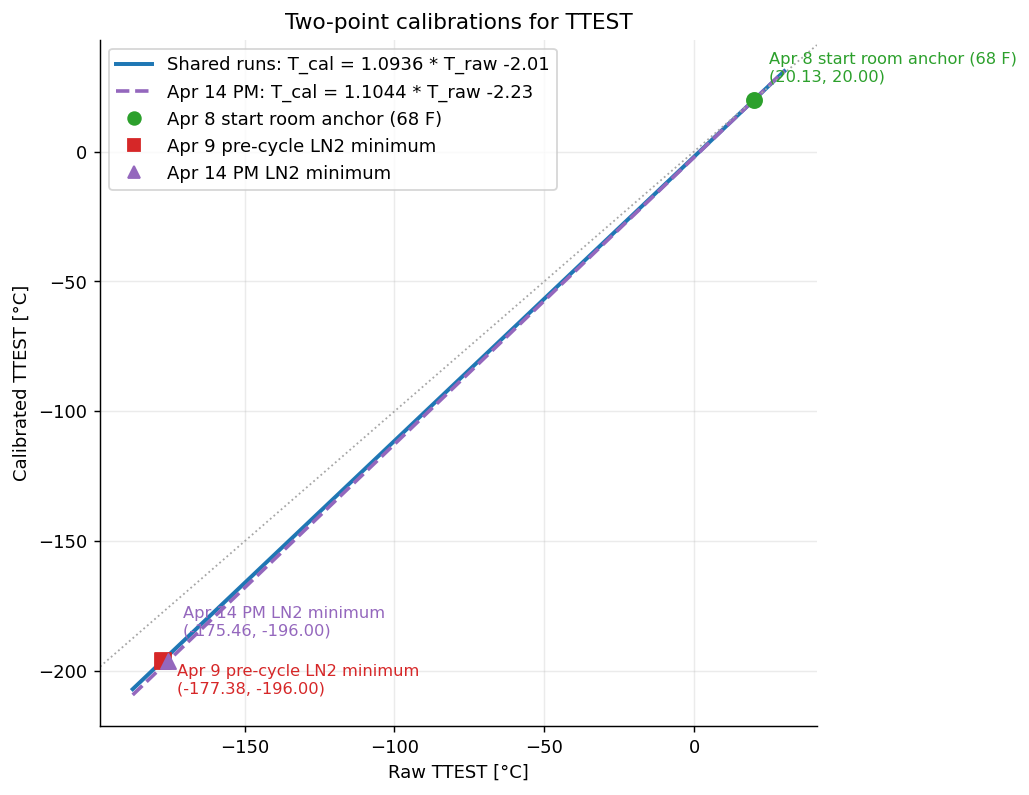

In [2]:
fig, ax = plt.subplots(figsize=(7.8, 6.0), constrained_layout=True)

raw_grid = np.linspace(min(cold_anchor_raw_c, apr14_pm_cold_anchor_raw_c) - 10.0, room_anchor_raw_c + 10.0, 200)
shared_cal_grid = calibration_gain * raw_grid + calibration_offset_c
apr14_pm_cal_grid = apr14_pm_calibration_gain * raw_grid + apr14_pm_calibration_offset_c

ax.plot(raw_grid, shared_cal_grid, color='C0', lw=2.2)
ax.plot(raw_grid, apr14_pm_cal_grid, color='C4', lw=2.0, ls='--')
ax.scatter(room_anchor_raw_c, room_anchor_true_c, color='C2', marker='o', s=70, zorder=3)
ax.scatter(cold_anchor_raw_c, ln2_reference_c, color='C3', marker='s', s=70, zorder=3)
ax.scatter(apr14_pm_cold_anchor_raw_c, ln2_reference_c, color='C4', marker='^', s=70, zorder=3)
ax.axline((0.0, 0.0), slope=1.0, color='0.65', lw=1.0, ls=':')

ax.annotate(
    f"Apr 8 start room anchor (68 F)\n({room_anchor_raw_c:.2f}, {room_anchor_true_c:.2f})",
    xy=(room_anchor_raw_c, room_anchor_true_c),
    xytext=(8, 10),
    textcoords='offset points',
    color='C2',
    fontsize=9,
)
ax.annotate(
    f"Apr 9 pre-cycle LN2 minimum\n({cold_anchor_raw_c:.2f}, {ln2_reference_c:.2f})",
    xy=(cold_anchor_raw_c, ln2_reference_c),
    xytext=(8, -18),
    textcoords='offset points',
    color='C3',
    fontsize=9,
)
ax.annotate(
    f"Apr 14 PM LN2 minimum\n({apr14_pm_cold_anchor_raw_c:.2f}, {ln2_reference_c:.2f})",
    xy=(apr14_pm_cold_anchor_raw_c, ln2_reference_c),
    xytext=(8, 14),
    textcoords='offset points',
    color='C4',
    fontsize=9,
)

legend_handles = [
    Line2D([], [], color='C0', lw=2.2, label=f"Shared runs: {calibration_summary.iloc[0]['Affine law']}"),
    Line2D([], [], color='C4', lw=2.0, ls='--', label=f"Apr 14 PM: {calibration_summary.iloc[1]['Affine law']}"),
    Line2D([], [], color='C2', marker='o', linestyle='', markersize=7, label='Apr 8 start room anchor (68 F)'),
    Line2D([], [], color='C3', marker='s', linestyle='', markersize=7, label='Apr 9 pre-cycle LN2 minimum'),
    Line2D([], [], color='C4', marker='^', linestyle='', markersize=7, label='Apr 14 PM LN2 minimum'),
]
ax.legend(handles=legend_handles, loc='best')

ax.set_xlabel('Raw TTEST [°C]')
ax.set_ylabel('Calibrated TTEST [°C]')
ax.set_title('Two-point calibrations for TTEST')

plt.show()


## HFE Temperature Evolution

Each test shows the pre-plunge, cooldown, and warmup phases. The Apr 9 run and the first Apr 14 run also separate the warmup in air from the warmup in insulation, while the later Apr 14 run warms only in insulation.

The time axis is referenced to the start of the cooldown (`t = 0`).

The 3M lines mark the transition temperatures reported in a 3M technical document for HFE-7200.


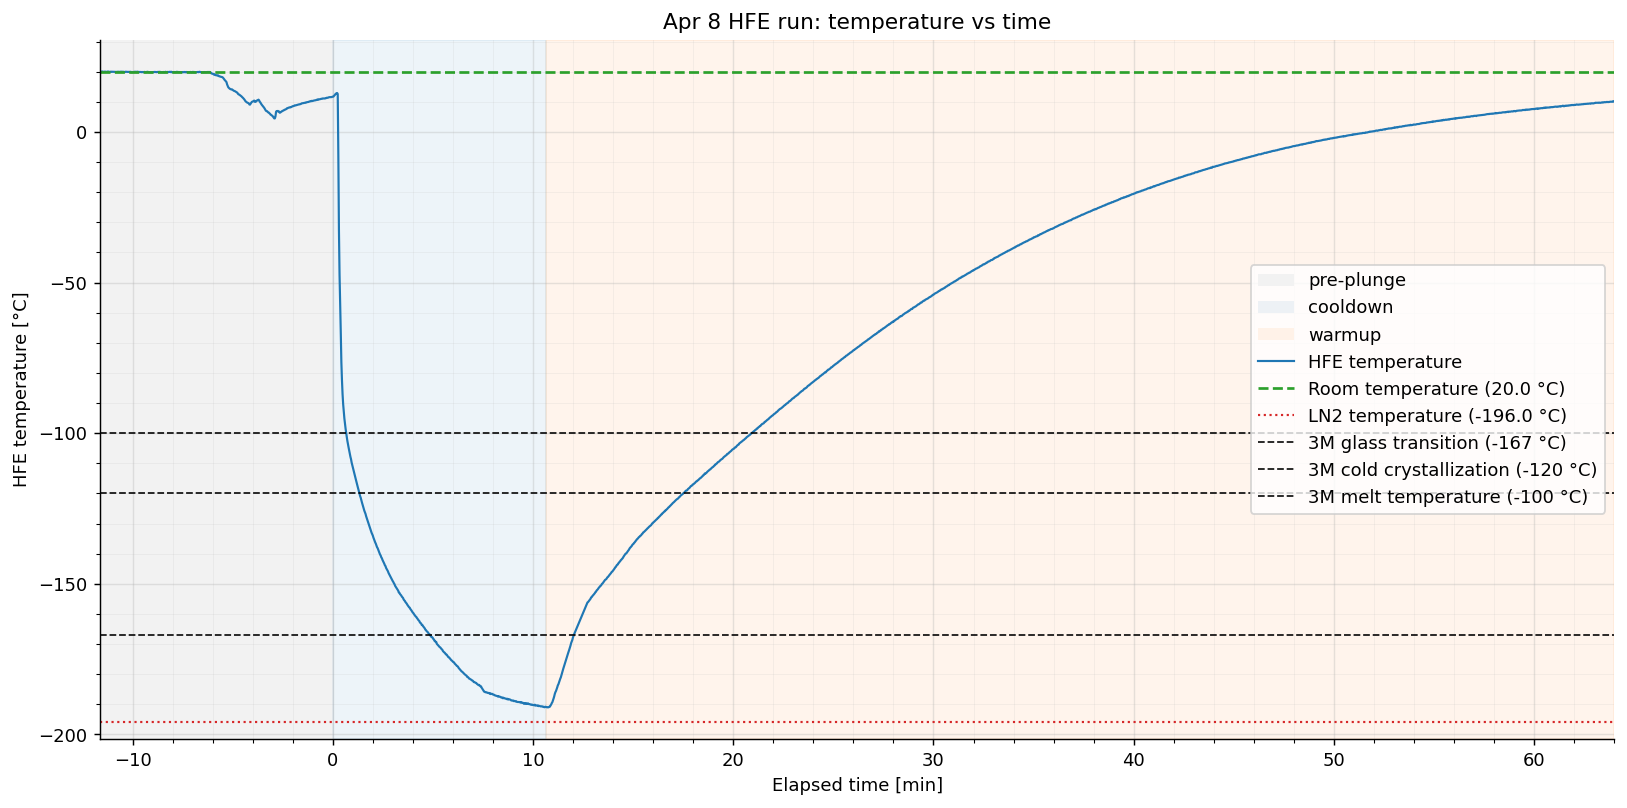

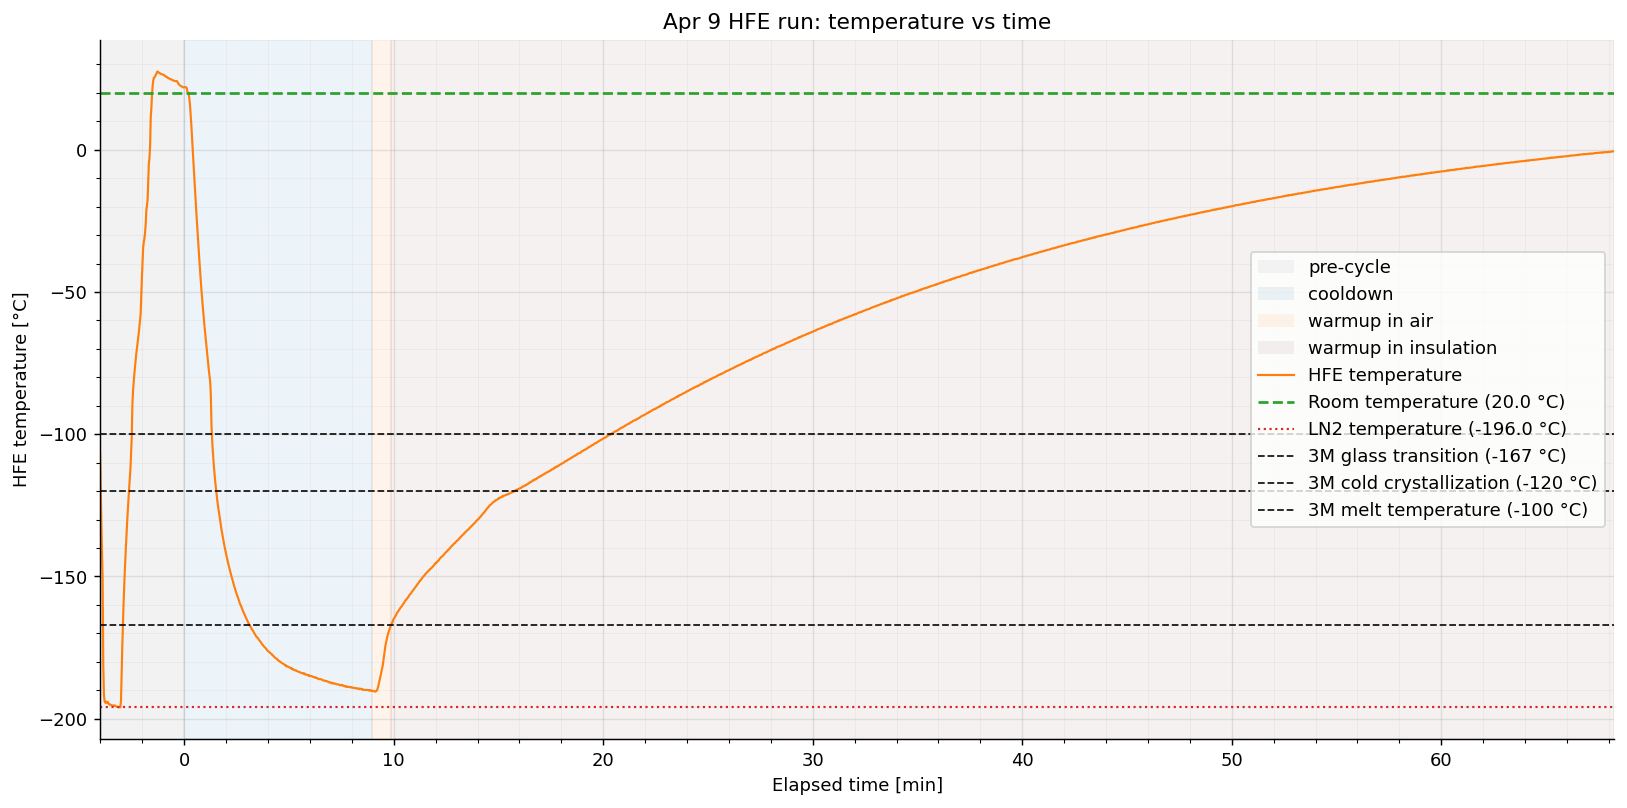

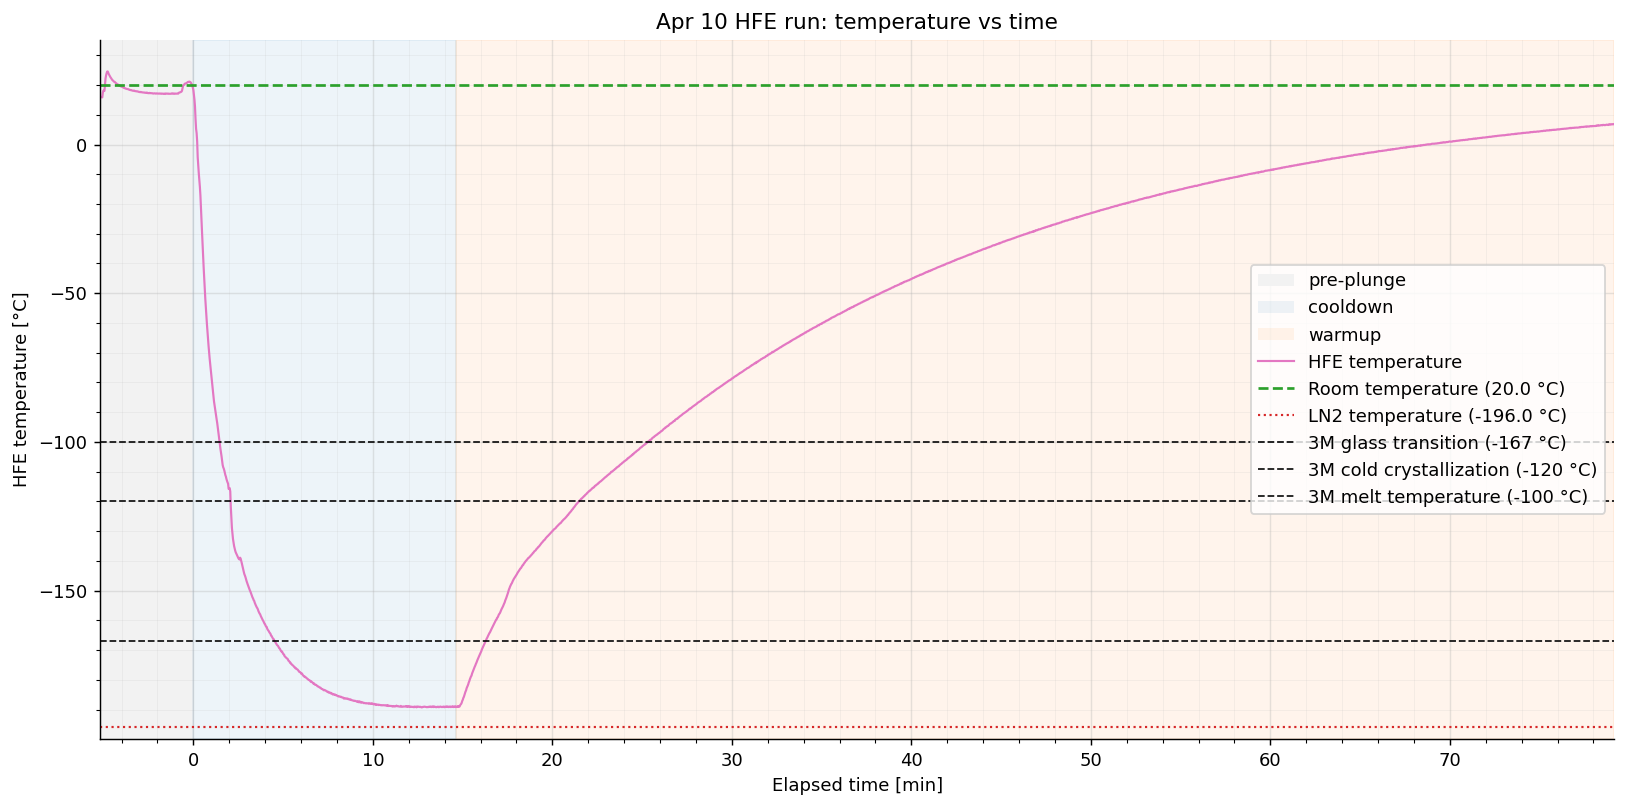

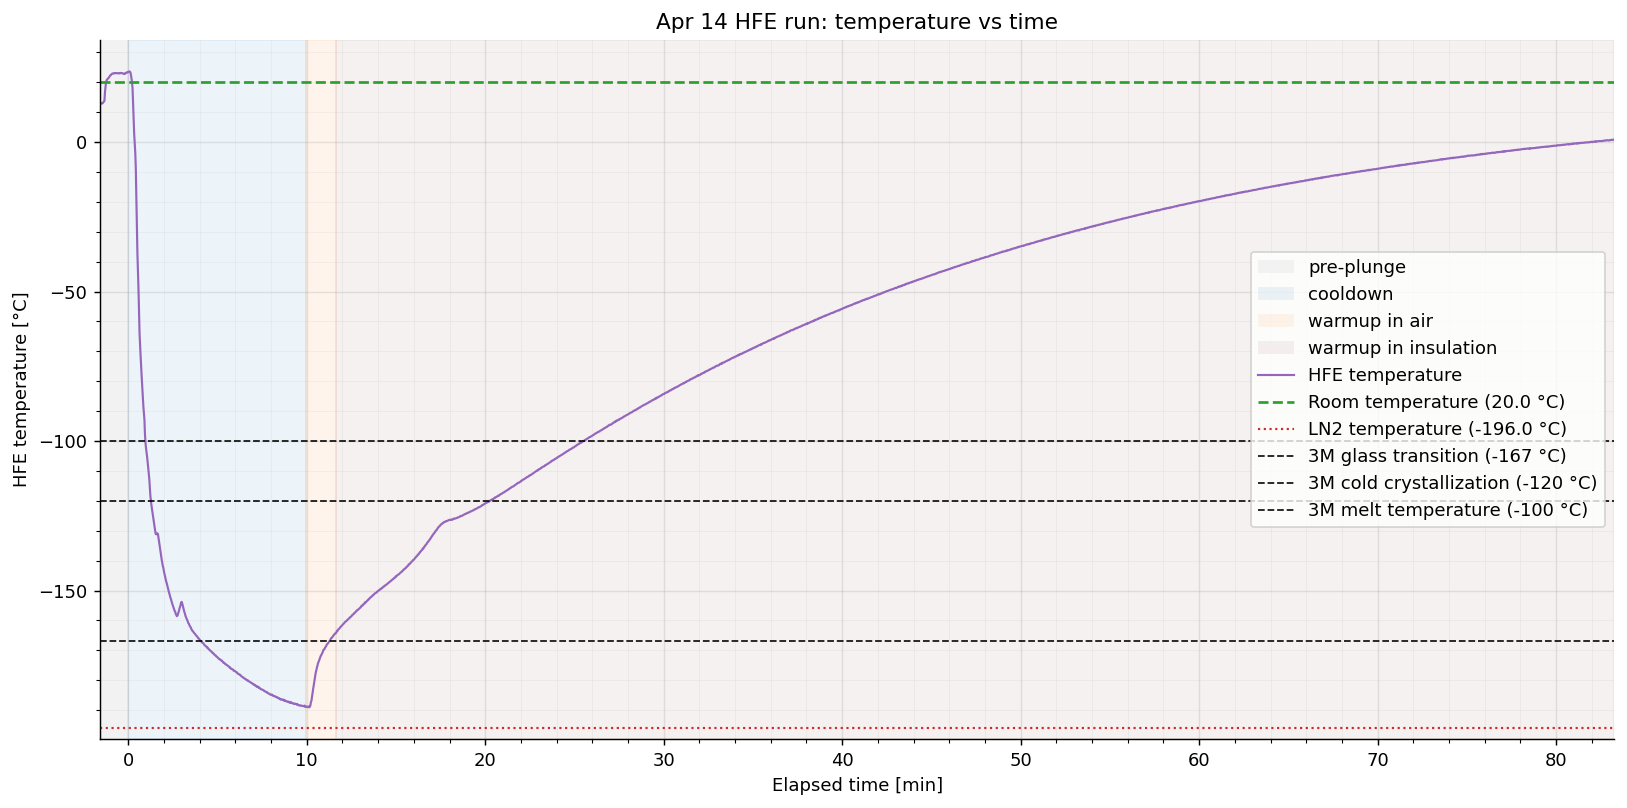

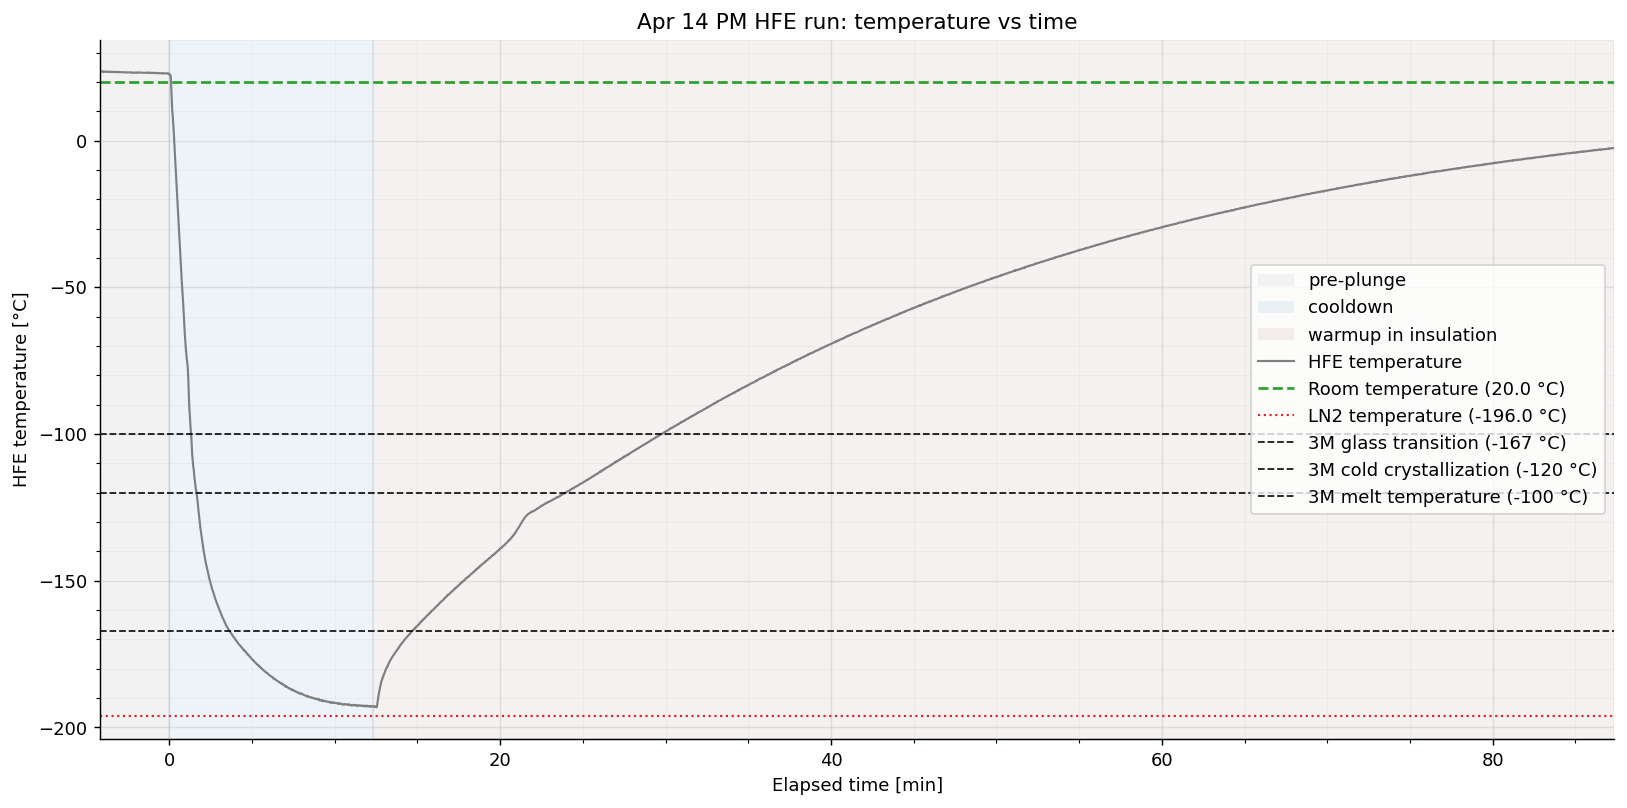

In [3]:
for name, spec in all_run_specs.items():
    frame = spec['data']
    fig, ax = plt.subplots(figsize=(12.4, 6.1), constrained_layout=True)

    pre_label = spec['pre_label']
    pre_start_time = float(frame['t_from_cooldown_min'].min())
    turnaround_time = float(frame.loc[spec['turnaround_index'], 't_from_cooldown_min'])
    final_time = float(frame['t_from_cooldown_min'].iloc[-1])

    ax.axvspan(pre_start_time, 0.0, color='0.95')
    ax.axvspan(0.0, turnaround_time, color='C0', alpha=0.08)

    legend_handles = [
        Patch(facecolor='0.95', edgecolor='none', label=pre_label),
        Patch(facecolor='C0', edgecolor='none', alpha=0.08, label='cooldown'),
    ]

    if 'air_band_end_time_from_cooldown_min' in spec:
        air_end_time = spec['air_band_end_time_from_cooldown_min']
        ax.axvspan(turnaround_time, air_end_time, color='C1', alpha=0.08)
        ax.axvspan(air_end_time, final_time, color='C5', alpha=0.08)
        legend_handles.extend([
            Patch(facecolor='C1', edgecolor='none', alpha=0.08, label='warmup in air'),
            Patch(facecolor='C5', edgecolor='none', alpha=0.08, label='warmup in insulation'),
        ])
    else:
        warmup_color = spec.get('warmup_shading_color', 'C1')
        warmup_label = spec.get('warmup_shading_label', 'warmup')
        ax.axvspan(turnaround_time, final_time, color=warmup_color, alpha=0.08)
        legend_handles.append(Patch(facecolor=warmup_color, edgecolor='none', alpha=0.08, label=warmup_label))

    ax.plot(
        frame['t_from_cooldown_min'],
        frame['probe_calibrated_raw_c'],
        color=spec['temperature_line_color'],
        lw=1.2,
    )
    ax.axhline(spec['room_temperature_c'], color='C2', lw=1.5, ls='--')
    ax.axhline(ln2_reference_c, color='C3', lw=1.2, ls=':')

    for reference in three_m_reference_points.values():
        ax.axhline(reference['temperature_c'], **three_m_line_kwargs)

    legend_handles.extend([
        Line2D([], [], color=spec['temperature_line_color'], lw=1.2, label='HFE temperature'),
        Line2D([], [], color='C2', lw=1.5, ls='--', label=f"Room temperature ({spec['room_temperature_c']:.1f} °C)"),
        Line2D([], [], color='C3', lw=1.2, ls=':', label=f"LN2 temperature ({ln2_reference_c:.1f} °C)"),
    ])
    legend_handles.extend([
        three_m_legend_handle(reference['label'])
        for reference in three_m_reference_points.values()
    ])

    ax.set_xlim(pre_start_time, final_time)
    ax.set_xlabel('Elapsed time [min]')
    ax.set_ylabel('HFE temperature [°C]')
    ax.set_title(f'{name}: temperature vs time')
    ax.minorticks_on()
    ax.grid(True, which='major', alpha=0.32)
    ax.grid(True, which='minor', alpha=0.14, linewidth=0.5)
    ax.legend(handles=legend_handles, loc='best')

    plt.show()


### HFE Cooldown and Warmup Temperature Rate

The plots below show the calibrated `dT/dt` values directly from the `30 s`-smoothed `TTEST` trace.

Small opposite-sign jitter near the phase boundaries is clipped at zero so cooldown stays on the negative side and warmup stays on the positive side. The 3M reference temperatures are shown as vertical lines.


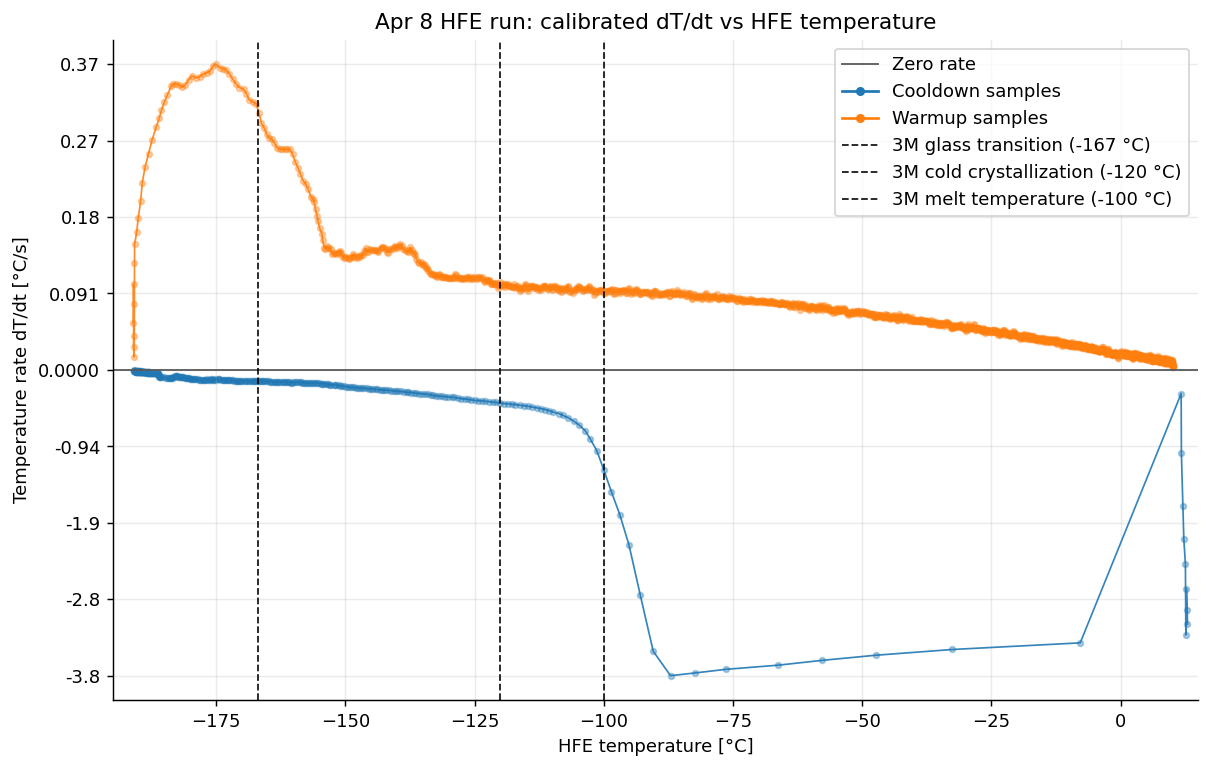

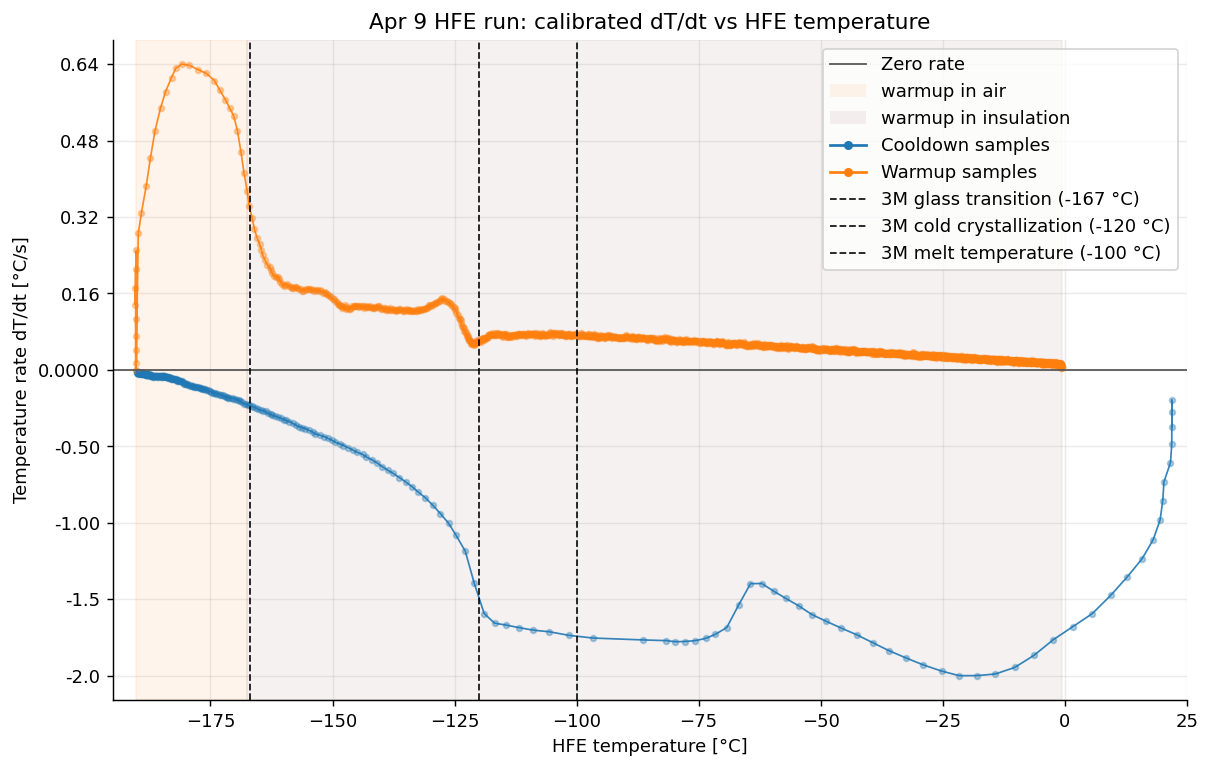

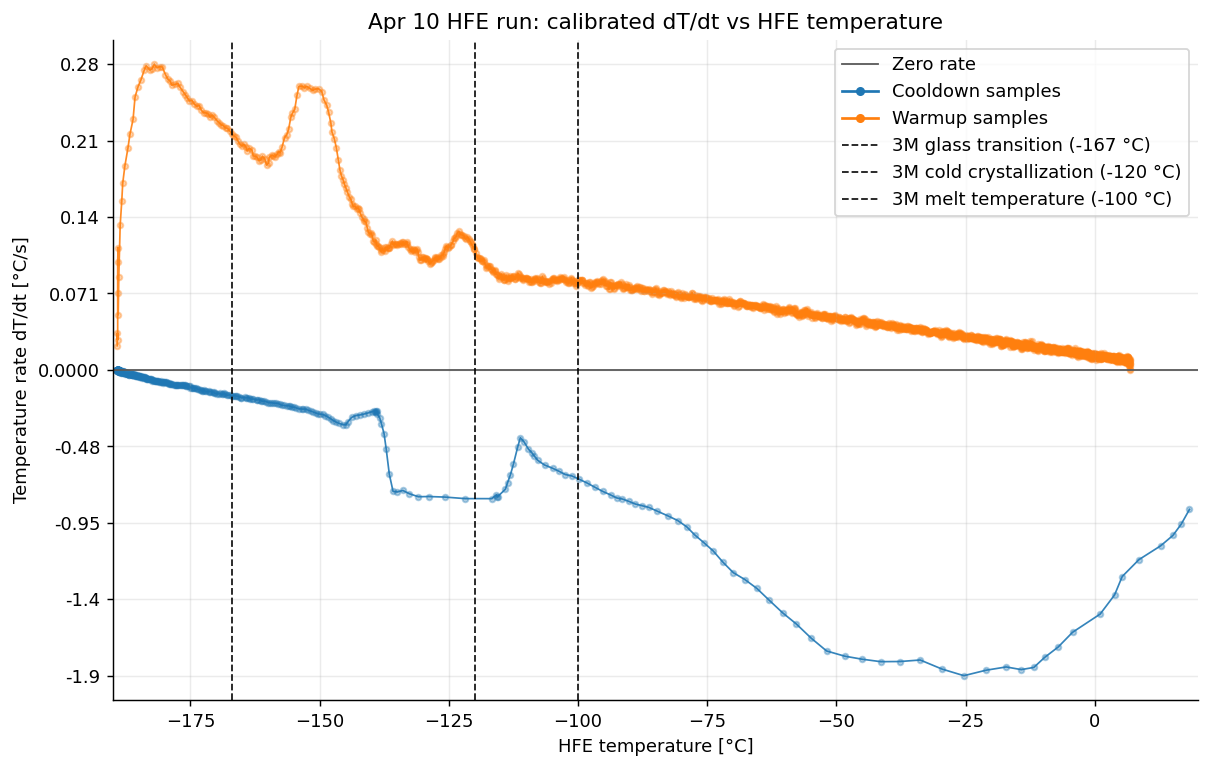

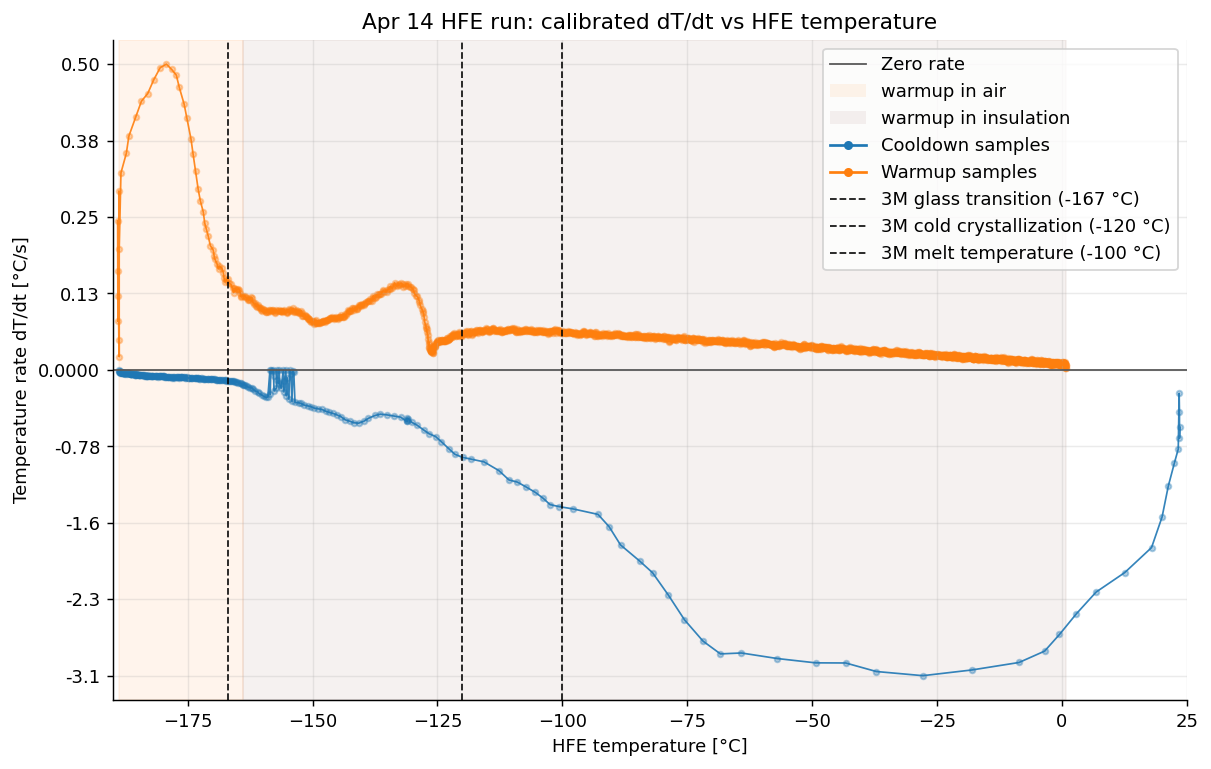

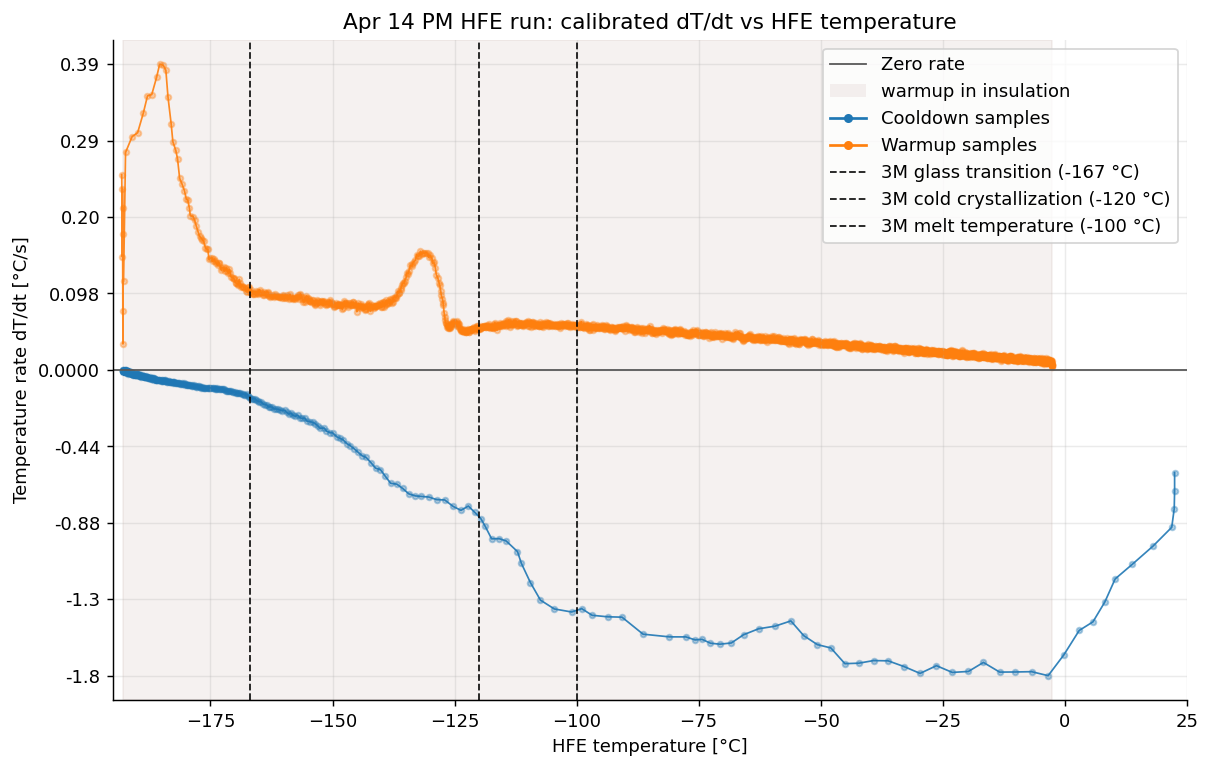

In [4]:
for name, spec in all_run_specs.items():
    frame = spec['data']
    fig, ax = plt.subplots(figsize=(9.2, 5.8), constrained_layout=True)

    phase_styles = {
        'cooldown': {'title': 'Cooldown', 'color': 'C0'},
        'warmup': {'title': 'Warmup', 'color': 'C1'},
    }

    phase_frames = {
        phase_name: frame.loc[
            frame['phase'] == phase_name,
            ['probe_calibrated_raw_c', 'probe_calibrated_rate_c_s'],
        ].dropna().sort_values('probe_calibrated_raw_c').reset_index(drop=True)
        for phase_name in phase_styles
    }

    cooldown_values = phase_frames['cooldown']['probe_calibrated_rate_c_s']
    warmup_values = phase_frames['warmup']['probe_calibrated_rate_c_s']
    cooldown_scale = abs(float(np.nanmin(cooldown_values))) if not cooldown_values.empty else 1.0
    warmup_scale = float(np.nanmax(warmup_values)) if not warmup_values.empty else 1.0
    cooldown_scale = cooldown_scale if np.isfinite(cooldown_scale) and cooldown_scale > 0.0 else 1.0
    warmup_scale = warmup_scale if np.isfinite(warmup_scale) and warmup_scale > 0.0 else 1.0

    def scale_signed_rates(values: np.ndarray | pd.Series) -> np.ndarray:
        rate_values = np.asarray(values, dtype=float)
        scaled = np.full(rate_values.shape, np.nan, dtype=float)
        positive_mask = rate_values >= 0.0
        negative_mask = rate_values < 0.0
        if positive_mask.any():
            scaled[positive_mask] = rate_values[positive_mask] / warmup_scale
        if negative_mask.any():
            scaled[negative_mask] = rate_values[negative_mask] / cooldown_scale
        return scaled

    def format_rate_tick(value: float) -> str:
        magnitude = abs(value)
        if magnitude >= 1.0:
            return f'{value:.1f}'
        if magnitude >= 0.1:
            return f'{value:.2f}'
        if magnitude >= 0.01:
            return f'{value:.3f}'
        return f'{value:.4f}'

    handles = [
        Line2D([], [], color='0.35', lw=1.0, label='Zero rate'),
    ]

    if 'air_band_high_calibrated_c' in spec:
        ax.axvspan(spec['air_band_low_calibrated_c'], spec['air_band_high_calibrated_c'], color='C1', alpha=0.08)
        ax.axvspan(spec['air_band_high_calibrated_c'], spec['insulation_band_high_calibrated_c'], color='C5', alpha=0.08)
        handles.extend([
            Patch(facecolor='C1', edgecolor='none', alpha=0.08, label='warmup in air'),
            Patch(facecolor='C5', edgecolor='none', alpha=0.08, label='warmup in insulation'),
        ])
    elif 'insulation_band_low_calibrated_c' in spec:
        warmup_color = spec.get('warmup_shading_color', 'C5')
        warmup_label = spec.get('warmup_shading_label', 'warmup in insulation')
        ax.axvspan(spec['insulation_band_low_calibrated_c'], spec['insulation_band_high_calibrated_c'], color=warmup_color, alpha=0.08)
        handles.append(Patch(facecolor=warmup_color, edgecolor='none', alpha=0.08, label=warmup_label))

    for phase_name, style in phase_styles.items():
        phase_frame = phase_frames[phase_name].copy()
        plot_rate = (
            phase_frame['probe_calibrated_rate_c_s'].clip(upper=0.0)
            if phase_name == 'cooldown'
            else phase_frame['probe_calibrated_rate_c_s'].clip(lower=0.0)
        )
        phase_frame['scaled_rate'] = scale_signed_rates(plot_rate)
        ax.plot(
            phase_frame['probe_calibrated_raw_c'],
            phase_frame['scaled_rate'],
            color=style['color'],
            lw=0.95,
            alpha=0.9,
        )
        ax.scatter(
            phase_frame['probe_calibrated_raw_c'],
            phase_frame['scaled_rate'],
            s=10,
            color=style['color'],
            alpha=0.35,
        )
        handles.append(
            Line2D([], [], color=style['color'], marker='o', linestyle='-', markersize=4, label=f"{style['title']} samples")
        )

    ax.axhline(0.0, color='0.35', lw=1.0)

    for reference in three_m_reference_points.values():
        ax.axvline(reference['temperature_c'], **three_m_line_kwargs)
    handles.extend([
        three_m_legend_handle(reference['label'])
        for reference in three_m_reference_points.values()
    ])

    negative_tick_values = np.linspace(-cooldown_scale, 0.0, 5)
    positive_tick_values = np.linspace(0.0, warmup_scale, 5)
    tick_values = np.concatenate([negative_tick_values[:-1], positive_tick_values])
    tick_positions = scale_signed_rates(tick_values)
    tick_labels = [format_rate_tick(value) for value in tick_values]

    ax.set_xlim(*spec['x_limits'])
    ax.set_ylim(-1.08, 1.08)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    ax.set_xlabel('HFE temperature [°C]')
    ax.set_ylabel('Temperature rate dT/dt [°C/s]')
    ax.set_title(f'{name}: calibrated dT/dt vs HFE temperature')
    ax.legend(handles=handles, loc='best')

    plt.show()


### Supplementary Outputs


In [5]:
display(
    calibration_summary.style.format(
        {
            'Room anchor raw [°C]': '{:.2f}',
            'Room anchor true [°C]': '{:.2f}',
            'Cold anchor raw [°C]': '{:.2f}',
            'Cold anchor true [°C]': '{:.2f}',
            'Calibration gain': '{:.6f}',
            'Calibration offset [°C]': '{:+.3f}',
        }
    )
)

display(
    run_summary.style.format(
        {
            'HFE fill volume [mL]': '{:.2f}',
            'Room temperature [°C]': '{:.2f}',
            'Cooldown start [min]': '{:.2f}',
            'Turnaround [min]': '{:.2f}',
            'Calibrated minimum [°C]': '{:.2f}',
            'Calibrated maximum [°C]': '{:.2f}',
            'Final calibrated temperature [°C]': '{:.2f}',
        }
    )
)


,Calibration set,Applies to,Calibration gain,Calibration offset [°C],Affine law,Room anchor source,Room anchor raw [°C],Room anchor true [°C],Cold anchor source,Cold anchor raw [°C],Cold anchor true [°C]
0,Shared runs,Apr 8 / 9 / 10 / 14,1.093616,-2.014,T_cal = 1.0936 * T_raw -2.01,Apr 8 start TTEST (68 F),20.13,20.00,Apr 9 pre-cycle LN2 minimum,-177.38,-196.00
1,Apr 14 PM run,Apr 14 PM,1.104351,-2.231,T_cal = 1.1044 * T_raw -2.23,Apr 8 start TTEST (68 F),20.13,20.00,log_20260414_172858 minimum,-175.46,-196.00


,Run,HFE fill volume [mL],Room temperature [°C],Cooldown start [min],Turnaround [min],Calibrated minimum [°C],Calibrated maximum [°C],Final calibrated temperature [°C],Warmup in air end [min],Air->insulation transition start [min],Air->insulation transition end [min],Warmup in insulation start [min]
0,Apr 8 HFE run,10.00,20.00,11.63,22.26,-190.86,20.01,10.08,nan,nan,nan,nan
1,Apr 9 HFE run,10.00,20.00,4.02,12.96,-195.56,26.63,-0.63,13.862750,13.862750,14.406383,14.406383
2,Apr 10 HFE run,10.00,20.00,5.20,19.81,-189.13,22.75,6.79,nan,nan,nan,nan
3,Apr 14 HFE run,14.70,20.00,1.57,11.54,-188.74,23.18,0.73,13.227736,nan,nan,13.227736
4,Apr 14 PM HFE run,14.70,20.00,4.18,16.50,-192.90,23.49,-2.61,nan,nan,nan,16.504167


## Results

Phase-transition-like features:
- liquid-to-solid transition around `-122 °C`
- glass-transition-like feature around `-167 °C`

These temperatures are broadly consistent with the 3M reference points.

Behavior at LXe temperature:
- the fluid still appears liquid
- no obvious "honey-like" viscosity was observed


## DSC-like Warmup Comparison

The notebook keeps two multi-run warmup comparisons below.

The first plot is the unadjusted warmup heat-flow comparison in `Exo Up` sense:
- each run uses the same warmup branch selection as the corrected plot below
- when an insulation warmup phase is identified, only that branch is used
- otherwise the full warmup branch is used
- the measured runs are plotted as `- q_{meas} / m`, so their up/down sense can be compared directly with the 3M DSC trace
- no background is removed from the measured runs
- the 3M digitized DSC curve is plotted unchanged

The second plot applies the earlier first-pass DSC-like correction. The warmup heat leak is modeled as a linear coupling to the `68 °F` (`20 °C`) room:
- `q_{bg,run}/m = - k_run (T_room - T_HFE)`
- `k_run` is fitted separately for each run
- only points in `-75 °C <= T_HFE <= 0 °C` are used for the fit

The plotted DSC-like `Exo Up` signal is `q_{event} = q_{bg} - q_{meas}`. The 3M curve in that corrected overview is only referenced to its own mean over `-75` to `0 °C` by a constant vertical shift, so its shape is unchanged.


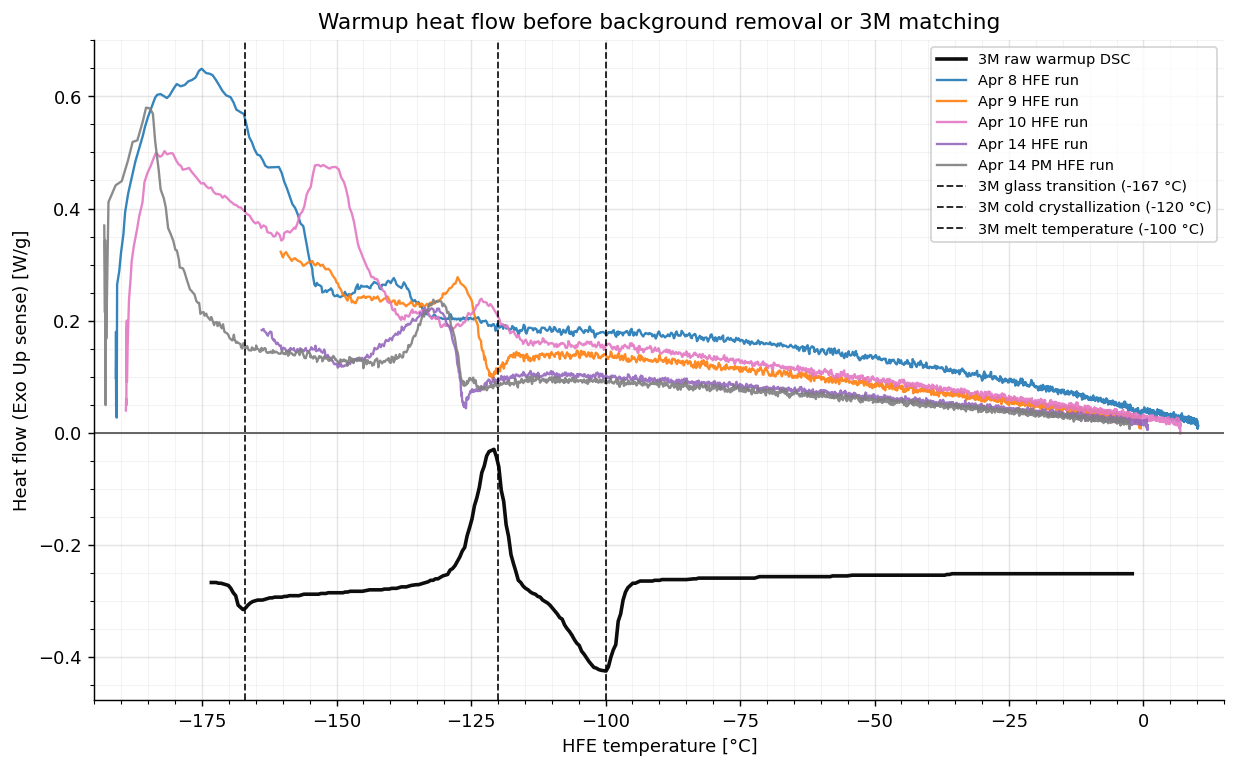

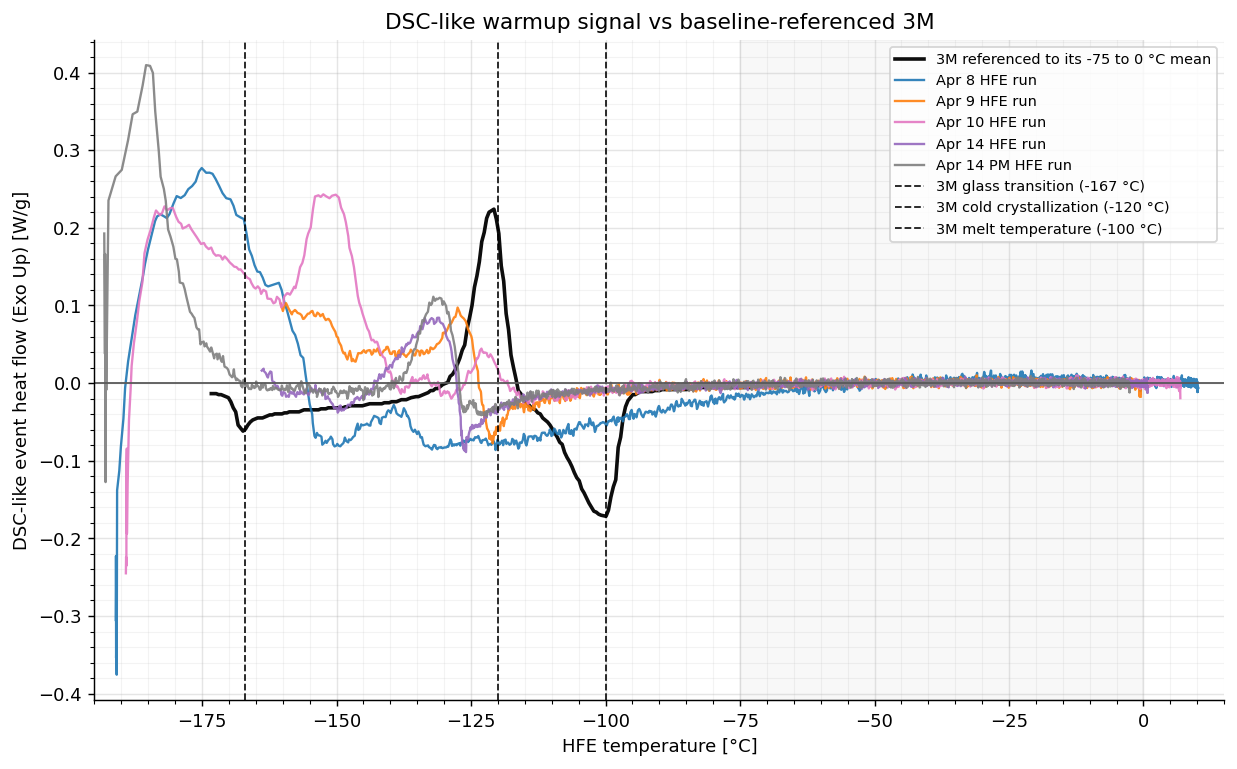

In [6]:
comparison_baseline_low_c = -75.0
comparison_baseline_high_c = 0.0

blue_curve_path = repo_root / 'data' / 'processed' / 'blue_curve_digitized.csv'
blue_curve = pd.read_csv(blue_curve_path).dropna(subset=['temperature_C', 'heat_flow_W_per_g']).copy()


def selected_warmup_frame(spec: dict) -> pd.DataFrame:
    warmup_frame = (
        spec['data']
        .loc[spec['data']['phase'] == 'warmup', ['probe_calibrated_raw_c', 'estimated_heat_flow_w_g', 't_rel_min']]
        .dropna()
        .sort_values('probe_calibrated_raw_c')
        .reset_index(drop=True)
        .copy()
    )
    if 'insulation_band_start_time_min' in spec:
        warmup_frame = warmup_frame.loc[
            warmup_frame['t_rel_min'].ge(spec['insulation_band_start_time_min'])
        ].reset_index(drop=True)
    return warmup_frame


raw_series = [blue_curve['heat_flow_W_per_g']]
raw_temperature_series = [blue_curve['temperature_C']]

raw_fig, raw_ax = plt.subplots(figsize=(9.4, 5.8), constrained_layout=True)
raw_ax.plot(
    blue_curve['temperature_C'],
    blue_curve['heat_flow_W_per_g'],
    color='black',
    lw=2.0,
    alpha=0.95,
    label='3M raw warmup DSC',
)

for name, spec in all_run_specs.items():
    warmup_frame = selected_warmup_frame(spec)
    if warmup_frame.empty:
        continue

    warmup_frame['raw_exo_up_heat_flow_w_g'] = -warmup_frame['estimated_heat_flow_w_g']

    raw_ax.plot(
        warmup_frame['probe_calibrated_raw_c'],
        warmup_frame['raw_exo_up_heat_flow_w_g'],
        color=spec['temperature_line_color'],
        lw=1.3,
        alpha=0.90,
        label=name,
    )
    raw_series.append(warmup_frame['raw_exo_up_heat_flow_w_g'])
    raw_temperature_series.append(warmup_frame['probe_calibrated_raw_c'])

for reference in three_m_reference_points.values():
    raw_ax.axvline(reference['temperature_c'], **three_m_line_kwargs)

raw_reference_handles = [
    three_m_legend_handle(reference['label'])
    for reference in three_m_reference_points.values()
]
raw_handles, raw_labels = raw_ax.get_legend_handles_labels()
raw_ax.legend(
    raw_handles + raw_reference_handles,
    raw_labels + [handle.get_label() for handle in raw_reference_handles],
    loc='best',
    fontsize=8,
)

raw_min = float(min(series.min() for series in raw_series))
raw_max = float(max(series.max() for series in raw_series))
raw_pad = 0.08 * max(abs(raw_min), abs(raw_max), 1.0e-6)
raw_plot_xmin_c = 5.0 * np.floor((min(float(series.min()) for series in raw_temperature_series) - 1.0) / 5.0)
raw_plot_xmax_c = 5.0 * np.ceil((max(float(series.max()) for series in raw_temperature_series) + 1.0) / 5.0)

raw_ax.axhline(0.0, color='0.35', lw=1.0)
raw_ax.set_xlabel('HFE temperature [°C]')
raw_ax.set_ylabel('Heat flow (Exo Up sense) [W/g]')
raw_ax.set_title('Warmup heat flow before background removal or 3M matching')
raw_ax.set_xlim(raw_plot_xmin_c, raw_plot_xmax_c)
raw_ax.set_ylim(raw_min - raw_pad, raw_max + raw_pad)
raw_ax.set_axisbelow(True)
raw_ax.minorticks_on()
raw_ax.grid(which='major', alpha=0.32)
raw_ax.grid(which='minor', alpha=0.14, linewidth=0.6)

plt.show()

blue_baseline_mask = blue_curve['temperature_C'].between(comparison_baseline_low_c, comparison_baseline_high_c)
blue_reference_level_w_g = float(blue_curve.loc[blue_baseline_mask, 'heat_flow_W_per_g'].mean())
blue_curve['baseline_referenced_heat_flow_w_g'] = blue_curve['heat_flow_W_per_g'] - blue_reference_level_w_g

corrected_series = [blue_curve['baseline_referenced_heat_flow_w_g']]
corrected_temperature_series = [blue_curve['temperature_C']]

fig, ax = plt.subplots(figsize=(9.4, 5.8), constrained_layout=True)
ax.axvspan(comparison_baseline_low_c, comparison_baseline_high_c, color='0.65', alpha=0.08)
ax.plot(
    blue_curve['temperature_C'],
    blue_curve['baseline_referenced_heat_flow_w_g'],
    color='black',
    lw=2.0,
    alpha=0.95,
    label='3M referenced to its -75 to 0 °C mean',
)

for name, spec in all_run_specs.items():
    warmup_frame = selected_warmup_frame(spec)
    if warmup_frame.empty:
        continue

    fit_mask = warmup_frame['probe_calibrated_raw_c'].between(comparison_baseline_low_c, comparison_baseline_high_c)
    fit_frame = warmup_frame.loc[fit_mask].copy()
    if fit_frame.empty:
        continue

    delta_t_fit_c = room_reference_c - fit_frame['probe_calibrated_raw_c']
    conductance_per_g_w_gk = float(
        -(
            fit_frame['estimated_heat_flow_w_g'] * delta_t_fit_c
        ).sum() / (delta_t_fit_c ** 2).sum()
    )

    warmup_frame['linear_background_w_g'] = -conductance_per_g_w_gk * (
        room_reference_c - warmup_frame['probe_calibrated_raw_c']
    )
    warmup_frame['dsc_like_event_heat_flow_w_g'] = (
        warmup_frame['linear_background_w_g'] - warmup_frame['estimated_heat_flow_w_g']
    )

    ax.plot(
        warmup_frame['probe_calibrated_raw_c'],
        warmup_frame['dsc_like_event_heat_flow_w_g'],
        color=spec['temperature_line_color'],
        lw=1.3,
        alpha=0.90,
        label=name,
    )
    corrected_series.append(warmup_frame['dsc_like_event_heat_flow_w_g'])
    corrected_temperature_series.append(warmup_frame['probe_calibrated_raw_c'])

for reference in three_m_reference_points.values():
    ax.axvline(reference['temperature_c'], **three_m_line_kwargs)

reference_handles = [
    three_m_legend_handle(reference['label'])
    for reference in three_m_reference_points.values()
]
corr_handles, corr_labels = ax.get_legend_handles_labels()
ax.legend(
    corr_handles + reference_handles,
    corr_labels + [handle.get_label() for handle in reference_handles],
    loc='best',
    fontsize=8,
)

corr_min = float(min(series.min() for series in corrected_series))
corr_max = float(max(series.max() for series in corrected_series))
corr_pad = 0.08 * max(abs(corr_min), abs(corr_max), 1.0e-6)
plot_xmin_c = 5.0 * np.floor((min(float(series.min()) for series in corrected_temperature_series) - 1.0) / 5.0)
plot_xmax_c = 5.0 * np.ceil((max(float(series.max()) for series in corrected_temperature_series) + 1.0) / 5.0)

ax.axhline(0.0, color='0.35', lw=1.0)
ax.set_xlabel('HFE temperature [°C]')
ax.set_ylabel('DSC-like event heat flow (Exo Up) [W/g]')
ax.set_title('DSC-like warmup signal vs baseline-referenced 3M')
ax.set_xlim(plot_xmin_c, plot_xmax_c)
ax.set_ylim(corr_min - corr_pad, corr_max + corr_pad)
ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(which='major', alpha=0.32)
ax.grid(which='minor', alpha=0.14, linewidth=0.6)

plt.show()


## Apr 14 PM Exo Up Comparison

This last figure keeps the raw 3M digitized warmup DSC curve and compares it only to the `Apr 14 PM HFE run` insulation warmup.

For the Apr 14 PM curve, the notebook first builds a DSC-like `Exo Up` signal from the measured warmup heat flow:
- `q_{bg}/m = - k_run (T_room - T_HFE)`
- `q_{DSC-like}/m = q_{bg}/m - q_{meas}/m`
- `T_room = 20.0 °C`
- `k_run` is fitted from the Apr 14 PM insulation warmup over `-75 °C` to `0 °C`

That keeps the Apr 14 PM variations in the same up/down sense as a proper `Exo Up` DSC plot.

The `-75 °C` to `0 °C` interval is then used only to match that Apr 14 PM DSC-like curve to the unchanged 3M curve with a simple additive baseline:
- `q_{plot}/m = q_{DSC-like}/m + a + b (T_room - T_HFE)`

That makes the comparison easier to read without claiming that environmental losses were independently removed from the 3M DSC trace.

The digitized 3M curve only reaches about `-173 °C`, while the Apr 14 PM trace goes down to about `-193 °C`. Below the cold end of the 3M digitization, the final comparison therefore shows only the measured Apr 14 PM trace.

The first plot in this section shows that adaptation explicitly: the Apr 14 PM DSC-like curve before the 3M match, the fitted correction term `a + b (T_room - T_HFE)`, and the final matched curve.

The table temperatures are extracted from the curves actually shown in the comparison plot:
- 3M: the smoothed digitized reference curve
- Apr 14 PM: the full matched DSC-like curve
- glass transition: fixed at `-167 °C` for both curves
- cold crystallization: maximum heat flow for `T > -167 °C`
- melt: minimum heat flow for `T > -167 °C`

For readability, the adaptation plot uses a light Savitzky-Golay smoothing with a maximum `5`-point window on the `1 °C` temperature bins. The final comparison plot itself uses the full Apr 14 PM matched dataset, so it keeps the same point density as the DSC-like plot above.

The final Apr 14 PM vs 3M plot is intentionally kept simple: no bootstrap band and no error bars, just the two DSC-like curves with feature markers.


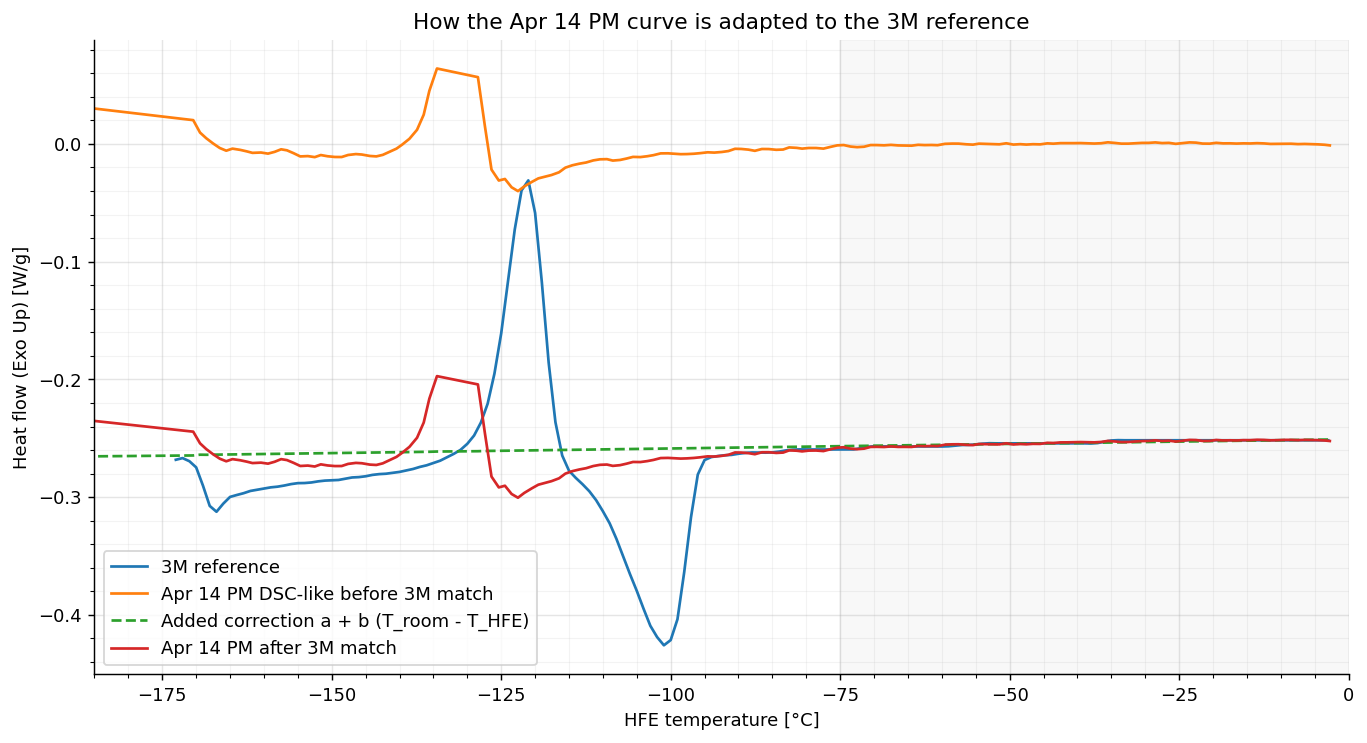

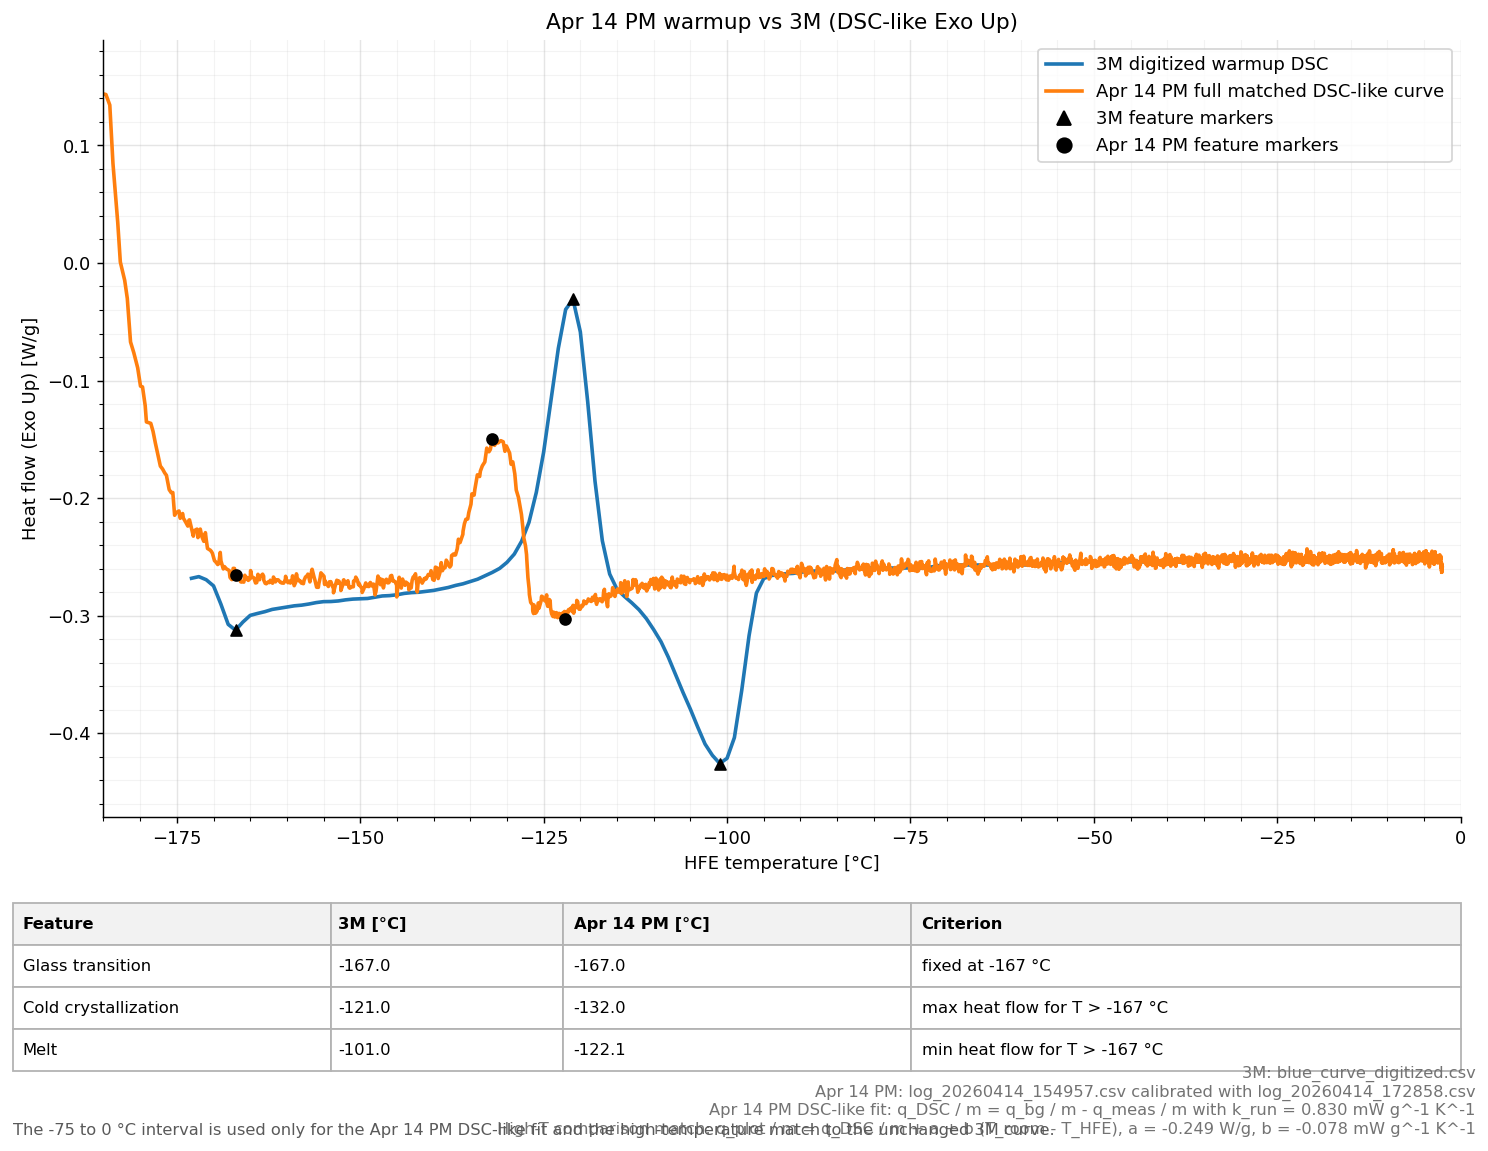

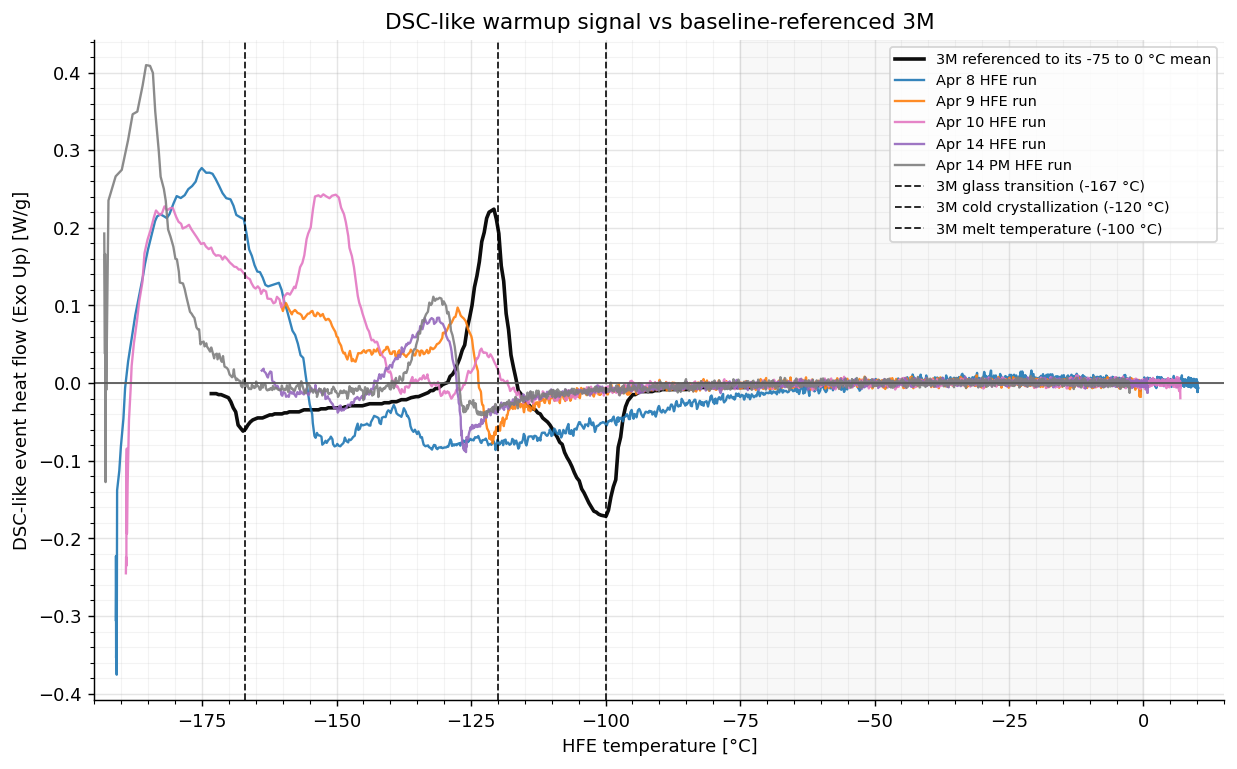

In [7]:
from scipy.signal import savgol_filter

comparison_fit_low_c = -75.0
comparison_fit_high_c = 0.0
bootstrap_bin_width_c = 1.0
feature_windows_c = {
    'glass_transition': {
        'label': 'Glass transition',
        'fixed_temperature_c': -167.0,
        'kind': 'fixed',
    },
    'cold_crystallization': {
        'label': 'Cold crystallization',
        'temperature_low_c': -167.0,
        'temperature_high_c': 0.0,
        'kind': 'max',
    },
    'melt_temperature': {
        'label': 'Melt',
        'temperature_low_c': -167.0,
        'temperature_high_c': 0.0,
        'kind': 'min',
    },
}

blue_curve_path = repo_root / 'data' / 'processed' / 'blue_curve_digitized.csv'
blue_curve = (
    pd.read_csv(blue_curve_path)
    .dropna(subset=['temperature_C', 'heat_flow_W_per_g'])
    .sort_values('temperature_C')
    .reset_index(drop=True)
    .copy()
)

apr14_pm_spec = all_run_specs['Apr 14 PM HFE run']
apr14_pm_warmup = (
    apr14_pm_spec['data']
    .loc[
        apr14_pm_spec['data']['phase'].eq('warmup')
        & apr14_pm_spec['data']['t_rel_min'].ge(apr14_pm_spec['insulation_band_start_time_min']),
        ['t_rel_min', 'probe_calibrated_raw_c', 'estimated_heat_flow_w_g'],
    ]
    .dropna()
    .sort_values('t_rel_min')
    .reset_index(drop=True)
    .copy()
)


def smooth_curve(values: np.ndarray, *, max_window_points: int = 5, polyorder: int = 2) -> np.ndarray:
    if len(values) == 0:
        return values
    window_points = min(max_window_points, len(values))
    if window_points % 2 == 0:
        window_points -= 1
    if window_points <= polyorder or window_points < 3:
        return values.copy()
    return savgol_filter(
        values,
        window_length=window_points,
        polyorder=min(polyorder, window_points - 1),
        mode='interp',
    )


def summarize_by_temperature(
    frame: pd.DataFrame,
    *,
    value_column: str,
    bin_width_c: float = 1.0,
    min_count: int = 5,
) -> pd.DataFrame:
    lower_edge_c = bin_width_c * np.floor(float(frame['probe_calibrated_raw_c'].min()) / bin_width_c)
    upper_edge_c = bin_width_c * np.ceil(float(frame['probe_calibrated_raw_c'].max()) / bin_width_c)
    bins = np.arange(lower_edge_c, upper_edge_c + bin_width_c, bin_width_c)
    if bins.size < 2:
        bins = np.array([lower_edge_c, lower_edge_c + bin_width_c], dtype=float)

    grouped = (
        frame
        .assign(temperature_bin=pd.cut(frame['probe_calibrated_raw_c'], bins=bins, include_lowest=True))
        .groupby('temperature_bin', observed=False)
    )
    summary = grouped.agg(
        temperature_c=('probe_calibrated_raw_c', 'median'),
        heat_flow_w_g=(value_column, 'median'),
        count=(value_column, 'size'),
    ).reset_index(drop=True)
    summary = summary.loc[summary['count'] >= min_count].reset_index(drop=True)
    if summary.empty:
        return summary
    summary['smoothed_heat_flow_w_g'] = smooth_curve(summary['heat_flow_w_g'].to_numpy())
    summary['smoothed_derivative_w_g_per_c'] = np.gradient(
        summary['smoothed_heat_flow_w_g'].to_numpy(),
        summary['temperature_c'].to_numpy(),
    )
    return summary


def compute_run_dsc_like(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    prepared = frame.sort_values('probe_calibrated_raw_c').reset_index(drop=True).copy()
    fit_frame = prepared.loc[
        prepared['probe_calibrated_raw_c'].between(comparison_fit_low_c, comparison_fit_high_c)
    ].copy()
    delta_t_fit_c = room_reference_c - fit_frame['probe_calibrated_raw_c']
    room_coupling_w_gk = float(
        -(
            fit_frame['estimated_heat_flow_w_g'] * delta_t_fit_c
        ).sum() / (delta_t_fit_c ** 2).sum()
    )
    prepared['run_background_w_g'] = -room_coupling_w_gk * (
        room_reference_c - prepared['probe_calibrated_raw_c']
    )
    prepared['dsc_like_heat_flow_w_g'] = (
        prepared['run_background_w_g'] - prepared['estimated_heat_flow_w_g']
    )
    return prepared, {
        'room_coupling_w_gk': room_coupling_w_gk,
    }


def match_dsc_like_to_three_m(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    matched = frame.sort_values('probe_calibrated_raw_c').reset_index(drop=True).copy()
    matched['three_m_heat_flow_w_g'] = np.interp(
        matched['probe_calibrated_raw_c'],
        blue_curve['temperature_C'],
        blue_curve['heat_flow_W_per_g'],
        left=np.nan,
        right=np.nan,
    )
    fit_frame = matched.loc[
        matched['probe_calibrated_raw_c'].between(comparison_fit_low_c, comparison_fit_high_c)
        & matched['three_m_heat_flow_w_g'].notna()
    ].copy()
    X = np.column_stack([
        np.ones(len(fit_frame), dtype=float),
        room_reference_c - fit_frame['probe_calibrated_raw_c'].to_numpy(),
    ])
    y = fit_frame['three_m_heat_flow_w_g'].to_numpy() - fit_frame['dsc_like_heat_flow_w_g'].to_numpy()
    background_offset_w_g, comparison_slope_w_gk = np.linalg.lstsq(X, y, rcond=None)[0]
    matched['comparison_baseline_w_g'] = background_offset_w_g + comparison_slope_w_gk * (
        room_reference_c - matched['probe_calibrated_raw_c']
    )
    matched['comparison_matched_heat_flow_w_g'] = (
        matched['dsc_like_heat_flow_w_g'] + matched['comparison_baseline_w_g']
    )
    return matched, {
        'background_offset_w_g': float(background_offset_w_g),
        'comparison_slope_w_gk': float(comparison_slope_w_gk),
    }


def extract_feature(
    curve_frame: pd.DataFrame,
    *,
    kind: str,
    low_c: float | None = None,
    high_c: float | None = None,
    fixed_temperature_c: float | None = None,
) -> dict:
    ordered_curve = (
        curve_frame[['temperature_c', 'smoothed_heat_flow_w_g', 'smoothed_derivative_w_g_per_c']]
        .dropna(subset=['temperature_c', 'smoothed_heat_flow_w_g'])
        .sort_values('temperature_c')
        .reset_index(drop=True)
    )
    if ordered_curve.empty:
        return {'temperature_c': np.nan, 'heat_flow_w_g': np.nan}
    if kind == 'fixed':
        if fixed_temperature_c is None:
            raise ValueError('fixed_temperature_c must be provided when kind="fixed"')
        temp_values_c = ordered_curve['temperature_c'].to_numpy()
        if fixed_temperature_c < float(temp_values_c.min()) or fixed_temperature_c > float(temp_values_c.max()):
            return {'temperature_c': np.nan, 'heat_flow_w_g': np.nan}
        heat_flow_w_g = np.interp(
            fixed_temperature_c,
            temp_values_c,
            ordered_curve['smoothed_heat_flow_w_g'].to_numpy(),
        )
        return {
            'temperature_c': float(fixed_temperature_c),
            'heat_flow_w_g': float(heat_flow_w_g),
        }
    if low_c is None or high_c is None:
        raise ValueError(f'low_c and high_c must be provided when kind={kind!r}')
    subset = ordered_curve.loc[ordered_curve['temperature_c'].between(low_c, high_c)].copy()
    if subset.empty:
        return {'temperature_c': np.nan, 'heat_flow_w_g': np.nan}
    if kind == 'max':
        row = subset.loc[subset['smoothed_heat_flow_w_g'].idxmax()]
    elif kind == 'min':
        row = subset.loc[subset['smoothed_heat_flow_w_g'].idxmin()]
    else:
        raise ValueError(f'Unsupported feature kind: {kind!r}')
    return {
        'temperature_c': float(row['temperature_c']),
        'heat_flow_w_g': float(row['smoothed_heat_flow_w_g']),
    }


three_m_temperature_grid_c = np.arange(
    np.ceil(float(blue_curve['temperature_C'].min())),
    np.floor(float(blue_curve['temperature_C'].max())) + bootstrap_bin_width_c,
    bootstrap_bin_width_c,
)
three_m_curve = pd.DataFrame({
    'temperature_c': three_m_temperature_grid_c,
    'heat_flow_w_g': np.interp(
        three_m_temperature_grid_c,
        blue_curve['temperature_C'],
        blue_curve['heat_flow_W_per_g'],
    ),
})
three_m_curve['smoothed_heat_flow_w_g'] = smooth_curve(three_m_curve['heat_flow_w_g'].to_numpy())
three_m_curve['smoothed_derivative_w_g_per_c'] = np.gradient(
    three_m_curve['smoothed_heat_flow_w_g'].to_numpy(),
    three_m_curve['temperature_c'].to_numpy(),
)

nominal_dsc_like, run_background_fit = compute_run_dsc_like(apr14_pm_warmup)
nominal_matched, comparison_match = match_dsc_like_to_three_m(nominal_dsc_like)
nominal_dsc_like_curve = summarize_by_temperature(
    nominal_dsc_like,
    value_column='dsc_like_heat_flow_w_g',
    bin_width_c=bootstrap_bin_width_c,
    min_count=5,
)
nominal_match_baseline_curve = summarize_by_temperature(
    nominal_matched,
    value_column='comparison_baseline_w_g',
    bin_width_c=bootstrap_bin_width_c,
    min_count=5,
)
nominal_curve = summarize_by_temperature(
    nominal_matched,
    value_column='comparison_matched_heat_flow_w_g',
    bin_width_c=bootstrap_bin_width_c,
    min_count=5,
)

three_m_feature_curve = three_m_curve[['temperature_c', 'smoothed_heat_flow_w_g', 'smoothed_derivative_w_g_per_c']].copy()
run_feature_curve = (
    nominal_matched[['probe_calibrated_raw_c', 'comparison_matched_heat_flow_w_g']]
    .dropna()
    .sort_values('probe_calibrated_raw_c')
    .rename(columns={
        'probe_calibrated_raw_c': 'temperature_c',
        'comparison_matched_heat_flow_w_g': 'smoothed_heat_flow_w_g',
    })
    .reset_index(drop=True)
)
run_feature_curve['smoothed_derivative_w_g_per_c'] = np.nan

feature_results_3m = {
    key: extract_feature(
        three_m_feature_curve,
        kind=spec['kind'],
        low_c=spec.get('temperature_low_c'),
        high_c=spec.get('temperature_high_c'),
        fixed_temperature_c=spec.get('fixed_temperature_c'),
    )
    for key, spec in feature_windows_c.items()
}
feature_results_run = {
    key: extract_feature(
        run_feature_curve,
        kind=spec['kind'],
        low_c=spec.get('temperature_low_c'),
        high_c=spec.get('temperature_high_c'),
        fixed_temperature_c=spec.get('fixed_temperature_c'),
    )
    for key, spec in feature_windows_c.items()
}

comparison_xmin_c = -185.0
comparison_xmax_c = 0.0

adaptation_fig, adaptation_axis = plt.subplots(figsize=(10.4, 5.6), constrained_layout=True)
adaptation_axis.axvspan(comparison_fit_low_c, comparison_fit_high_c, color='0.65', alpha=0.08)
adaptation_axis.plot(
    three_m_curve['temperature_c'],
    three_m_curve['smoothed_heat_flow_w_g'],
    label='3M reference',
)
adaptation_axis.plot(
    nominal_dsc_like_curve['temperature_c'],
    nominal_dsc_like_curve['smoothed_heat_flow_w_g'],
    label='Apr 14 PM DSC-like before 3M match',
)
adaptation_axis.plot(
    nominal_match_baseline_curve['temperature_c'],
    nominal_match_baseline_curve['smoothed_heat_flow_w_g'],
    linestyle='--',
    label='Added correction a + b (T_room - T_HFE)',
)
adaptation_axis.plot(
    nominal_curve['temperature_c'],
    nominal_curve['smoothed_heat_flow_w_g'],
    label='Apr 14 PM after 3M match',
)
adaptation_axis.set_xlim(comparison_xmin_c, comparison_xmax_c)
adaptation_axis.set_xlabel('HFE temperature [°C]')
adaptation_axis.set_ylabel('Heat flow (Exo Up) [W/g]')
adaptation_axis.set_title('How the Apr 14 PM curve is adapted to the 3M reference')
adaptation_axis.set_axisbelow(True)
adaptation_axis.minorticks_on()
adaptation_axis.grid(which='major', alpha=0.32)
adaptation_axis.grid(which='minor', alpha=0.14, linewidth=0.6)
adaptation_axis.legend(loc='best')
display(adaptation_fig)
plt.close(adaptation_fig)

fig = plt.figure(figsize=(11.6, 9.6))
grid = fig.add_gridspec(2, 1, height_ratios=[8.0, 2.4], hspace=0.05)
axis = fig.add_subplot(grid[0])
table_axis = fig.add_subplot(grid[1])
table_axis.axis('off')

three_m_line, = axis.plot(
    three_m_curve['temperature_c'],
    three_m_curve['smoothed_heat_flow_w_g'],
    linewidth=2.0,
    label='3M digitized warmup DSC',
)
run_line, = axis.plot(
    nominal_matched['probe_calibrated_raw_c'],
    nominal_matched['comparison_matched_heat_flow_w_g'],
    linewidth=2.0,
    label='Apr 14 PM full matched DSC-like curve',
)

for key, spec in feature_windows_c.items():
    three_m_feature = feature_results_3m[key]
    run_feature = feature_results_run[key]
    axis.scatter(
        [three_m_feature['temperature_c']],
        [three_m_feature['heat_flow_w_g']],
        marker='^',
        color='black',
        zorder=7,
    )
    axis.scatter(
        [run_feature['temperature_c']],
        [run_feature['heat_flow_w_g']],
        marker='o',
        color='black',
        zorder=8,
    )

legend_handles = [
    Line2D([], [], color=three_m_line.get_color(), linewidth=2.0, label='3M digitized warmup DSC'),
    Line2D([], [], color=run_line.get_color(), linewidth=2.0, label='Apr 14 PM full matched DSC-like curve'),
    Line2D([], [], color='black', marker='^', linestyle='None', markersize=8, label='3M feature markers'),
    Line2D(
        [],
        [],
        color='black',
        marker='o',
        linestyle='None',
        markersize=8,
        label='Apr 14 PM feature markers',
    ),
]
axis.legend(handles=legend_handles, loc='best')

curve_y_min = float(np.nanmin([three_m_curve['smoothed_heat_flow_w_g'].min(), nominal_matched['comparison_matched_heat_flow_w_g'].min()]))
curve_y_max = float(np.nanmax([three_m_curve['smoothed_heat_flow_w_g'].max(), nominal_matched['comparison_matched_heat_flow_w_g'].max()]))
y_pad = 0.08 * max(curve_y_max - curve_y_min, 0.02)

axis.set_xlim(comparison_xmin_c, comparison_xmax_c)
axis.set_ylim(curve_y_min - y_pad, curve_y_max + y_pad)
axis.set_xlabel('HFE temperature [°C]')
axis.set_ylabel('Heat flow (Exo Up) [W/g]')
axis.set_title('Apr 14 PM warmup vs 3M (DSC-like Exo Up)')
axis.set_axisbelow(True)
axis.minorticks_on()
axis.grid(which='major', alpha=0.32)
axis.grid(which='minor', alpha=0.14, linewidth=0.6)

feature_table_rows = []
for key, spec in feature_windows_c.items():
    if spec['kind'] == 'fixed':
        criterion_text = f"fixed at {spec['fixed_temperature_c']:.0f} °C"
    else:
        criterion_label = {
            'max': 'max heat flow',
            'min': 'min heat flow',
        }[spec['kind']]
        criterion_text = f"{criterion_label} for T > {spec['temperature_low_c']:.0f} °C"
    feature_table_rows.append([
        spec['label'],
        f"{feature_results_3m[key]['temperature_c']:.1f}",
        f"{feature_results_run[key]['temperature_c']:.1f}",
        criterion_text,
    ])

table = table_axis.table(
    cellText=feature_table_rows,
    colLabels=['Feature', '3M [°C]', 'Apr 14 PM [°C]', 'Criterion'],
    cellLoc='left',
    colLoc='left',
    bbox=(0.0, 0.02, 1.0, 0.72),
    colWidths=[0.22, 0.16, 0.24, 0.38],
)
table.auto_set_font_size(False)
table.set_fontsize(9.1)
table.scale(1.0, 1.55)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('0.7')
    cell.PAD = 0.02 if col == 3 else 0.03
    if row == 0:
        cell.set_facecolor('#f2f2f2')
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('white')
        cell.get_text().set_multialignment('left')

fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.10)
table_position = table_axis.get_position()
table_axis.set_position([0.02, table_position.y0, 0.96, table_position.height])
fig.text(
    0.99,
    0.050,
    (
        '3M: blue_curve_digitized.csv\n'
        'Apr 14 PM: log_20260414_154957.csv calibrated with log_20260414_172858.csv\n'
        f"Apr 14 PM DSC-like fit: q_DSC / m = q_bg / m - q_meas / m with k_run = {run_background_fit['room_coupling_w_gk'] * 1000.0:.3f} mW g^-1 K^-1\n"
        f"High-T comparison match: q_plot / m = q_DSC / m + a + b (T_room - T_HFE), a = {comparison_match['background_offset_w_g']:.3f} W/g, "
        f"b = {comparison_match['comparison_slope_w_gk'] * 1000.0:.3f} mW g^-1 K^-1"
    ),
    ha='right',
    va='bottom',
    fontsize=9,
    color='0.45',
)
fig.text(
    0.02,
    0.050,
    'The -75 to 0 °C interval is used only for the Apr 14 PM DSC-like fit and the high-temperature match to the unchanged 3M curve.',
    ha='left',
    va='bottom',
    fontsize=9,
    color='0.35',
)

display(fig)
plt.close(fig)

overview_blue_curve = blue_curve.copy()
overview_blue_baseline_mask = overview_blue_curve['temperature_C'].between(comparison_fit_low_c, comparison_fit_high_c)
overview_blue_reference_level_w_g = float(overview_blue_curve.loc[overview_blue_baseline_mask, 'heat_flow_W_per_g'].mean())
overview_blue_curve['baseline_referenced_heat_flow_w_g'] = overview_blue_curve['heat_flow_W_per_g'] - overview_blue_reference_level_w_g

overview_series = [overview_blue_curve['baseline_referenced_heat_flow_w_g']]
overview_temperature_series = [overview_blue_curve['temperature_C']]
overview_fig, overview_axis = plt.subplots(figsize=(9.4, 5.8), constrained_layout=True)
overview_axis.axvspan(comparison_fit_low_c, comparison_fit_high_c, color='0.65', alpha=0.08)
overview_axis.plot(
    overview_blue_curve['temperature_C'],
    overview_blue_curve['baseline_referenced_heat_flow_w_g'],
    color='black',
    lw=2.0,
    alpha=0.95,
    label='3M referenced to its -75 to 0 °C mean',
)

for name, spec in all_run_specs.items():
    overview_warmup = (
        spec['data']
        .loc[spec['data']['phase'] == 'warmup', ['probe_calibrated_raw_c', 'estimated_heat_flow_w_g', 't_rel_min']]
        .dropna()
        .sort_values('probe_calibrated_raw_c')
        .reset_index(drop=True)
        .copy()
    )
    if 'insulation_band_start_time_min' in spec:
        overview_warmup = overview_warmup.loc[
            overview_warmup['t_rel_min'].ge(spec['insulation_band_start_time_min'])
        ].reset_index(drop=True)
    if overview_warmup.empty:
        continue

    overview_fit_mask = overview_warmup['probe_calibrated_raw_c'].between(comparison_fit_low_c, comparison_fit_high_c)
    if not overview_fit_mask.any():
        continue

    overview_dsc_like, _ = compute_run_dsc_like(overview_warmup)
    overview_axis.plot(
        overview_dsc_like['probe_calibrated_raw_c'],
        overview_dsc_like['dsc_like_heat_flow_w_g'],
        color=spec['temperature_line_color'],
        lw=1.3,
        alpha=0.90,
        label=name,
    )
    overview_series.append(overview_dsc_like['dsc_like_heat_flow_w_g'])
    overview_temperature_series.append(overview_dsc_like['probe_calibrated_raw_c'])

for reference in three_m_reference_points.values():
    overview_axis.axvline(reference['temperature_c'], **three_m_line_kwargs)

overview_reference_handles = [
    three_m_legend_handle(reference['label'])
    for reference in three_m_reference_points.values()
]
overview_handles, overview_labels = overview_axis.get_legend_handles_labels()
overview_axis.legend(
    overview_handles + overview_reference_handles,
    overview_labels + [handle.get_label() for handle in overview_reference_handles],
    loc='best',
    fontsize=8,
)

overview_ymin = float(min(series.min() for series in overview_series))
overview_ymax = float(max(series.max() for series in overview_series))
overview_ypad = 0.08 * max(abs(overview_ymin), abs(overview_ymax), 1.0e-6)
overview_xmin = 5.0 * np.floor((min(float(series.min()) for series in overview_temperature_series) - 1.0) / 5.0)
overview_xmax = 5.0 * np.ceil((max(float(series.max()) for series in overview_temperature_series) + 1.0) / 5.0)

overview_axis.axhline(0.0, color='0.35', lw=1.0)
overview_axis.set_xlabel('HFE temperature [°C]')
overview_axis.set_ylabel('DSC-like event heat flow (Exo Up) [W/g]')
overview_axis.set_title('DSC-like warmup signal vs baseline-referenced 3M')
overview_axis.set_xlim(overview_xmin, overview_xmax)
overview_axis.set_ylim(overview_ymin - overview_ypad, overview_ymax + overview_ypad)
overview_axis.set_axisbelow(True)
overview_axis.minorticks_on()
overview_axis.grid(which='major', alpha=0.32)
overview_axis.grid(which='minor', alpha=0.14, linewidth=0.6)

display(overview_fig)
plt.close(overview_fig)
